# Modifying SEOBNRv5HMROM for $M=10^6M_\odot$ mass-ratio scan

This notebook builds frequency-domain injections by using `SEOBNRv5HMROM` as the carrier waveform and transferring the mode-by-mode amplitude and phase changes obtained from deviated `pSEOBNRv5HM` waveforms. For each mode, the construction is

$$
\tilde h_{\ell m}^{\mathrm{mod}}(f)
=\tilde h_{\ell m}^{\mathrm{ROM}}(f)
\frac{A_{\ell m}^{\mathrm{dev}}(f)}{A_{\ell m}^{\mathrm{GR}}(f)}
\exp\!\left\{i\left[\phi_{\ell m}^{\mathrm{dev}}(f)-\phi_{\ell m}^{\mathrm{GR}}(f)\right]\right\}.
$$

The total mass is fixed at $M=10^6M_\odot$, the mass ratio is scanned over $q\in\{1,2,3,4,5\}$, and every case uses $\delta\Omega=\delta\tau=0.01$ in the $(2,2)$ mode. All remaining source, response, and numerical settings are retained from the previous injection notebook. Each mass ratio is written to its own `q1` through `q5` subfolder with a q-tagged filename so that the matching recovery notebook can load the cases independently.


In [1]:
import copy
import json
import os
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import astropy.units as u
from astropy.cosmology import Planck15 as cosmo
from pyseobnr.generate_waveform import GenerateWaveform


/pbs/home/a/amahdi/.conda/envs/lisabeta/lib/python3.10/site-packages/pyseobnr/generate_waveform.py:6: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa


In [3]:
%matplotlib inline


## 1. Plotting

Let's set one plotting style here so that the diagnostic figures remain consistent throughout this notebook.


In [4]:
plot_style = {
    "font.family": "serif",
    "axes.unicode_minus": False,
    "text.usetex": False,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.linewidth": 1.0,
    "hist.bins": 50,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "savefig.bbox": "tight",
    "savefig.transparent": True,
    "figure.dpi": 100,
}

plt.rcParams.update(plot_style)


## 2. Directories

In [5]:
Syst_dir = os.path.expanduser("/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio")
os.makedirs(Syst_dir, exist_ok=True)

# A distinct tag and root for the fixed-deviation mass-ratio scan
deviation_tag = "domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5"

Output_root = os.path.join(
    Syst_dir,
    "SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_" + deviation_tag,
)
os.makedirs(Output_root, exist_ok=True)

print("Syst_dir:", Syst_dir)
print("Writing the q scan under Output_root:", Output_root)


Syst_dir: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio
Writing the q scan under Output_root: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5


## 3. Waveform configuration

Defining the modes, deviation values, and common waveform settings before starting the scan.


In [6]:
common_modes = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]

# Total mass is fixed, and scanning only the mass ratio
MASS_VALUE = 1e6
MASS_LABEL = "M1e6"
Q_VALUES = np.array([1.0, 2.0, 3.0, 4.0], dtype=float)
Q_LABELS = ["q1", "q2", "q3", "q4"]

if len(Q_VALUES) != len(Q_LABELS):
    raise ValueError("Q_VALUES and Q_LABELS must have the same length.")

# Applying the same 0.01 frequency and damping-time deviation to every q value
DEVIATION_VALUE = 0.01
N = len(Q_VALUES)
deviation_values = np.full(N, DEVIATION_VALUE, dtype=float)
deviation_modes = [(2, 2)]

OVERWRITE_OUTPUTS = True

# Using the mass and q labels to distinguish individual output files
output_tag = "rom_pseob_ratio_phase_" + deviation_tag

d_omega = DEVIATION_VALUE
d_tau = DEVIATION_VALUE


def make_deviation_dicts(d_omega_value, d_tau_value, modes=None):
    """Building pySEOBNR dOmega/dTau dictionaries for one q case."""
    if modes is None:
        modes = common_modes

    domega_this = {
        f"{l},{m}": (float(d_omega_value) if (l, m) in deviation_modes else 0.0)
        for (l, m) in modes
    }
    dtau_this = {
        f"{l},{m}": (float(d_tau_value) if (l, m) in deviation_modes else 0.0)
        for (l, m) in modes
    }
    return domega_this, dtau_this


domega_dict, dtau_dict = make_deviation_dicts(d_omega, d_tau, modes=common_modes)

print("Modes:", common_modes)
print("Fixed total mass:", MASS_VALUE)
print("Mass label:", MASS_LABEL)
print("Mass-ratio values:", Q_VALUES)
print("q folders:", Q_LABELS)
print("Deviation value:", DEVIATION_VALUE)
print("Deviation tag:", deviation_tag)
print("domega_dict:", domega_dict)
print("dtau_dict:", dtau_dict)


Modes: [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
Fixed total mass: 1000000.0
Mass label: M1e6
Mass-ratio values: [1. 2. 3. 4.]
q folders: ['q1', 'q2', 'q3', 'q4']
Deviation value: 0.01
Deviation tag: domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5
domega_dict: {'2,2': 0.01, '2,1': 0.0, '3,3': 0.0, '4,4': 0.0, '4,3': 0.0, '5,5': 0.0}
dtau_dict: {'2,2': 0.01, '2,1': 0.0, '3,3': 0.0, '4,4': 0.0, '4,3': 0.0, '5,5': 0.0}


In [7]:
# ------------------------------------------------------------
# Setting the pSEOB configuration used for constructing the multiplier
# ------------------------------------------------------------

waveform_params_pseob_gr = {
    "t0": 0.0,
    "minf": 1e-5,
    "maxf": 0.2,

    "T_obs": 60 * 86400,
    "max_td_samples": 2_000_000,
    "deltaT": None,

    "approximant": "SEOBNRv5HM",
    "modes": common_modes,
    "n_freq": 10000,

    "timetomerger_max": 2.0,
    "DeltalnMf_max": 0.01,
    "TDIrescaled": True,
    "TDI": "TDIAET",
    "LISAnoise": copy.deepcopy(pyLISAnoise.LISAnoiseSciRDv1),
}

waveform_params_pseob_gr["LISAnoise"]["WDbackground"] = True
waveform_params_pseob_gr["LISAnoise"]["WDduration"] = 4.0

# Keep a default deviated configuration and rebuild the deviation dictionaries for every injection inside the main loop
waveform_params_pseob_dev = copy.deepcopy(waveform_params_pseob_gr)
waveform_params_pseob_dev.update({
    "domega_dict": domega_dict,
    "dtau_dict": dtau_dict,
})

# Reusing the GR configuration as the default in the pSEOB helper functions
waveform_params_base = waveform_params_pseob_gr

# ------------------------------------------------------------
# Setting the ROM carrier and LISA response configuration
# ------------------------------------------------------------

waveform_params_rom = {
    "minf": 1e-5,
    "maxf": 0.5,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "fend": None,
    "tmin": None,
    "tmax": None,
    "phiref": 0.0,
    "fref_for_phiref": 0.0,
    "tref": 0.0,
    "fref_for_tref": 0.0,
    "force_phiref_fref": True,
    "toffset": 0.0,
    "modes": common_modes,
    "TDI": "TDIAET",
    "acc": 0.0001,
    "order_fresnel_stencil": 0,
    "approximant": "SEOBNRv5HMROM",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": True,
    "LISAnoise": {
        "InstrumentalNoise": "SciRDv1",
        "WDbackground": True,
        "WDduration": 4.0,
        "lowf_add_pm_noise_f0": 0.0,
        "lowf_add_pm_noise_alpha": 2.0,
    },
}

print("pSEOB approximant used for multipliers:", waveform_params_pseob_gr["approximant"])
print("ROM carrier approximant:", waveform_params_rom["approximant"])


pSEOB approximant used for multipliers: SEOBNRv5HM
ROM carrier approximant: SEOBNRv5HMROM


## 4. Construct the pSEOB waveforms

We generate the pSEOB modes in the time domain, apply the time-domain window, and transform each mode onto a common frequency grid.


In [8]:
# Time-domain downsampling from the spline interpolation error

def Deltat_insp(nu, t, acc=1e-4, tc=0.):
    Lambda = 8./3 * np.pi**(5./12) * (acc * nu)**(1./4)
    return 8*Lambda/3 * 5./(256*nu) * (256*nu/5 * (tc-t))**(27/32.)

def downsamplemask_arr_byfunc(x, func_dx):
    mask_ds = np.zeros_like(x, dtype=bool)
    i = 0
    while (i < len(x)-1):
        mask_ds[i] = True
        dx = x[i+1] - x[i]
        dx_func = func_dx(x[i])
        i += int(dx_func/dx)
    mask_ds[len(x)-1] = True
    return mask_ds


In [9]:
def mode_key_variants(lm):
    l, m = lm
    return [lm, (l, m), f"{l},{m}", f"{l}{m}", f"h{l}{m}"]


def get_mode_from_dict(hlm, lm):
    for key in mode_key_variants(lm):
        if key in hlm:
            return hlm[key]
    raise KeyError(f"Mode {lm} not found. Available keys: {list(hlm.keys())[:20]}")


def choose_f_start_from_Tobs(m1, m2, waveform_params):
    f_min_user = waveform_params.get("minf", 1e-5)
    T_obs = waveform_params.get("T_obs", 60 * 86400)
    f_from_T = pytools.funcNewtonianfoft(m1, m2, T_obs)
    return max(f_min_user, f_from_T), T_obs, f_from_T


def choose_deltaT(M, waveform_params):
    maxf = float(waveform_params.get("maxf", 0.2))
    user_deltaT = waveform_params.get("deltaT", None)

    M_seconds = M * pyconstants.MTSUN_SI
    f_rd_est = 0.08 / M_seconds

    delta_from_maxf = 1.0 / (4.0 * maxf)
    delta_from_ringdown = 1.0 / (8.0 * f_rd_est)
    auto_deltaT = min(delta_from_maxf, delta_from_ringdown)

    if user_deltaT is None:
        return auto_deltaT, f_rd_est

    return min(float(user_deltaT), auto_deltaT), f_rd_est


def generate_pseob_td(params, modes=None, waveform_params=None, verbose=True):

    if waveform_params is None:
        waveform_params = waveform_params_base

    if modes is None:
        modes = waveform_params.get(
            "modes",
            [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
        )

    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    chi1 = float(params.get("chi1", 0.0))
    chi2 = float(params.get("chi2", 0.0))

    distance = float(params.get("dist", 1.0))
    inclination = float(params.get("inc", 0.0))
    phi_ref = float(params.get("phi", 0.0))

    f_min, T_obs, f_from_T = choose_f_start_from_Tobs(m1, m2, waveform_params)
    f_max = float(waveform_params.get("maxf", 0.2))

    deltaT, f_rd_est = choose_deltaT(M, waveform_params)

    approx = waveform_params.get("approximant", "SEOBNRv5HM")

    params_pseob = {
        "mass1": m1,
        "mass2": m2,
        "spin1x": 0.0,
        "spin1y": 0.0,
        "spin1z": chi1,
        "spin2x": 0.0,
        "spin2y": 0.0,
        "spin2z": chi2,
        "distance": distance,
        "inclination": inclination,
        "phi_ref": phi_ref,
        "f22_start": f_min,
        "f_ref": f_min,
        "f_max": f_max,
        "deltaT": deltaT,
        "approximant": approx,
        "mode_array": modes,
    }

    for key in ["domega_dict", "dtau_dict", "dA_dict", "dw_dict", "lmax_nyquist"]:
        if key in waveform_params:
            params_pseob[key] = waveform_params[key]

    if verbose:
        print(
            f"pySEOBNR TD: M={M:.3e}, q={q:.3f}, "
            f"chi1={chi1:.3f}, chi2={chi2:.3f}, "
            f"f22_start={f_min:.3e} Hz, f_from_T={f_from_T:.3e} Hz, "
            f"f_RD_est={f_rd_est:.3e} Hz, f_max={f_max:.3e} Hz, "
            f"deltaT={deltaT:.3e} s"
        )

    times, hlm_raw = GenerateWaveform(params_pseob).generate_td_modes()
    times = np.asarray(times)

    hlm_out = {}

    for lm in modes:
        try:
            hlm_out[lm] = np.asarray(get_mode_from_dict(hlm_raw, lm), dtype=complex)
        except KeyError:
            warnings.warn(f"Requested mode {lm} was not returned by pySEOBNR. Skipping.")

    if not hlm_out:
        raise RuntimeError(f"No requested modes returned. Available keys: {list(hlm_raw.keys())[:20]}")

    return times, hlm_out


def generate_pseob_fft(
    params,
    modes=None,
    waveform_params=None,
    verbose=True,
):

    if waveform_params is None:
        waveform_params = waveform_params_base

    if modes is None:
        modes = waveform_params.get(
            "modes",
            [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
        )

    Deltat_w_end = 40.0
    Deltat_w_beg = 10000.0

    minf = float(waveform_params.get("minf", 1e-5))
    maxf = float(waveform_params.get("maxf", 0.2))
    n_freq = int(waveform_params.get("n_freq", 10000))

    # Generating the pSEOB modes in the time domain

    t, h = generate_pseob_td(
        params,
        modes=modes,
        waveform_params=waveform_params,
        verbose=verbose,
    )

    # Checking the uniform time sampling required by the FFT
    dt_arr = np.diff(t)

    if len(dt_arr) == 0:
        raise ValueError("The time-domain waveform has fewer than two samples.")

    if not np.allclose(dt_arr, dt_arr[0], rtol=1e-5, atol=0):
        raise ValueError(
            "pySEOBNR returned a non-uniform time grid. "
            "This original-style FFT cell assumes uniform sampling."
        )


    w = pytools.window_planck_vec(t, t[0], t[-1], Deltat_w_beg, Deltat_w_end)

    hlm_fft = {}

    for lm in modes:
        if lm not in h:
            warnings.warn(f"Mode {lm} missing from pSEOB TD output. Skipping.")
            continue

        hlm_ts = np.array([
            t,
            w * np.real(h[lm]),
            w * np.imag(h[lm])
        ]).T

        hlm_ts = pytools.zeropad(hlm_ts, extend=1)

        # Using the same positive-frequency FFT convention as the injection code
        hlm_fs = pytools.fft_positivef(hlm_ts)

        freq = hlm_fs[:, 0]
        hf = hlm_fs[:, 1] + 1j * hlm_fs[:, 2]

        amp = np.abs(hf)
        phase = np.unwrap(np.angle(hf))

        hlm_fft[lm] = {}
        hlm_fft[lm]["freq"] = freq
        hlm_fft[lm]["amp"] = amp
        hlm_fft[lm]["phase"] = phase

    if not hlm_fft:
        raise RuntimeError("No modes were converted to frequency domain.")


    # Interpolate the modes onto a common geometric frequency grid


    f_low_available = max([hlm_fft[lm]["freq"][0] for lm in hlm_fft])
    f_high_available = min([hlm_fft[lm]["freq"][-1] for lm in hlm_fft])

    if minf < f_low_available:
        raise ValueError(
            f"minf={minf:.6e} is not covered by all pSEOB FFT modes. "
            f"The common lower limit is {f_low_available:.6e}."
        )

    if maxf > f_high_available:
        raise ValueError(
            f"maxf={maxf:.6e} is not covered by all pSEOB FFT modes. "
            f"The common upper limit is {f_high_available:.6e}."
        )

    freq = np.geomspace(minf, maxf, n_freq)

    hlm_fd = {}

    for lm in modes:
        if lm not in hlm_fft:
            continue

        spline_amp_fft = pytools.spline(
            hlm_fft[lm]["freq"],
            hlm_fft[lm]["amp"]
        )

        spline_phase_fft = pytools.spline(
            hlm_fft[lm]["freq"],
            hlm_fft[lm]["phase"]
        )

        mask_fft = (
            (hlm_fft[lm]["freq"][0] <= freq)
            & (freq <= hlm_fft[lm]["freq"][-1])
        )

        amp = np.zeros_like(freq)
        phase = np.zeros_like(freq)

        amp[mask_fft] = spline_amp_fft(freq[mask_fft])
        phase[mask_fft] = spline_phase_fft(freq[mask_fft])

        hlm_fd[lm] = {}
        hlm_fd[lm]["freq"] = freq.copy()
        hlm_fd[lm]["amp"] = amp.copy()
        hlm_fd[lm]["phase"] = phase.copy()

        hlm_fd[lm]["tf"] = (
            1.0 / (2.0 * np.pi)
            * pytools.spline(
                hlm_fd[lm]["freq"],
                hlm_fd[lm]["phase"]
            )(hlm_fd[lm]["freq"], 1)
        )

        hlm_fd[lm]["h"] = (
            hlm_fd[lm]["amp"]
            * np.exp(1j * hlm_fd[lm]["phase"])
        )

    if verbose:
        print("pSEOB FD construction:")
        print("  modes kept =", list(hlm_fd.keys()))
        print("  freq range =", freq[0], freq[-1])
        print("  n_freq     =", len(freq))

    return hlm_fd


In [10]:
def build_wftdi_from_hlm_fd(
    params,
    hlm_fd,
    modes,
    t0=0.0,
    TDI="TDIAET",
    TDIrescaled=True,
):

    params_local = copy.deepcopy(params)

    if params_local.get("Lframe", False):
        params_local = lisatools.convert_Lframe_to_SSBframe(params_local, t0=t0)
        params_local["Lframe"] = False

    Deltat = params_local["Deltat"]
    inc = params_local["inc"]
    phi = params_local["phi"]
    lambd = params_local["lambda"]
    beta = params_local["beta"]
    psi = params_local["psi"]

    wftdi = {"modes": []}

    for lm in modes:
        if lm not in hlm_fd:
            warnings.warn(f"Mode {lm} missing from hlm_fd. Skipping.")
            continue

        freq = np.asarray(hlm_fd[lm]["freq"])
        amp = np.asarray(hlm_fd[lm]["amp"])
        phase = np.asarray(hlm_fd[lm]["phase"])
        tf = np.asarray(hlm_fd[lm]["tf"])

        good = (
            np.isfinite(freq)
            & np.isfinite(amp)
            & np.isfinite(phase)
            & np.isfinite(tf)
            & (freq > 0)
        )

        freq = freq[good]
        amp = amp[good]
        phase = phase[good]
        tf = tf[good]

        if len(freq) < 10:
            warnings.warn(f"Mode {lm} has too few valid FD samples. Skipping.")
            continue

        wftdi["modes"].append(lm)

        wftdi[lm] = {}
        wftdi[lm]["freq"] = freq
        wftdi[lm]["amp"] = amp
        wftdi[lm]["phase"] = phase + (2.0 * np.pi) * freq * Deltat
        wftdi[lm]["tf"] = tf + Deltat

        tdiClass = pyresponse.LISAFDresponseTDI3Chan(
            wftdi[lm]["freq"],
            wftdi[lm]["tf"],
            t0,
            lm[0],
            lm[1],
            inc,
            phi,
            lambd,
            beta,
            psi,
            TDI=TDI,
            TDIrescaled=TDIrescaled,
        )

        (
            wftdi[lm]["phaseRdelay"],
            wftdi[lm]["transferL1"],
            wftdi[lm]["transferL2"],
            wftdi[lm]["transferL3"],
        ) = tdiClass.get_response()

    if not wftdi["modes"]:
        raise RuntimeError("No modes were available for TDI response construction.")

    return params_local, wftdi


def make_frequency_grid_from_hlm_fd(
    params,
    hlm_fd,
    waveform_params=None,
    Deltalnf=5e-4,
    refine=1,
):

    if waveform_params is None:
        waveform_params = waveform_params_base

    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    modes = waveform_params.get("modes", list(hlm_fd.keys()))

    f_lows = []
    f_highs = []

    for lm in modes:
        if lm not in hlm_fd:
            continue

        f = np.asarray(hlm_fd[lm]["freq"])
        f = f[np.isfinite(f) & (f > 0)]

        if len(f) < 2:
            continue

        f_lows.append(f[0])
        f_highs.append(f[-1])

    if len(f_lows) == 0:
        raise RuntimeError("Cannot build frequency grid: no valid mode frequency arrays.")

    fLow = np.fmax(max(f_lows), waveform_params.get("minf", 1e-5))
    fHigh = np.fmin(min(f_highs), waveform_params.get("maxf", 0.2))

    T_est = pytools.funcNewtoniantoff(m1, m2, fLow)
    T = np.fmin(pyconstants.YRSID_SI, np.fmax(30.0 * 86400.0, T_est))

    fLow = np.fmax(fLow, pytools.funcNewtonianfoft(m1, m2, T))

    if not (fLow < fHigh):
        raise ValueError(f"Bad response frequency range: fLow={fLow}, fHigh={fHigh}")

    freq_nyq_log = pytools.composite_nyquist_log_freq_grid(
        fLow,
        fHigh,
        m1,
        m2,
        Deltalnf=Deltalnf,
        refine=refine,
    )

    return freq_nyq_log


## 5. Building the mode-by-mode multiplier

We compare the GR and deviated pSEOB modes on their common frequency support and constructing

$$
R_{\ell m}(f)=\frac{A_{\ell m}^{\mathrm{dev}}(f)}{A_{\ell m}^{\mathrm{GR}}(f)}
\exp\!\left[i\,\Delta\phi_{\ell m}(f)\right].
$$

Only a constant phase offset is removed at the lowest retained frequency. Any frequency-dependent phase difference is kept.


In [11]:
def interp_to_reference_frequency(mode_data, f_ref):

    f = np.asarray(mode_data["freq"])
    amp = np.asarray(mode_data["amp"])
    phase = np.unwrap(np.asarray(mode_data["phase"]))

    good = np.isfinite(f) & np.isfinite(amp) & np.isfinite(phase) & (f > 0) & (amp >= 0)
    f = f[good]
    amp = amp[good]
    phase = phase[good]

    order = np.argsort(f)
    f = f[order]
    amp = amp[order]
    phase = phase[order]

    mask = (f_ref >= f[0]) & (f_ref <= f[-1])
    amp_ref = np.full_like(f_ref, np.nan, dtype=float)
    phase_ref = np.full_like(f_ref, np.nan, dtype=float)

    amp_ref[mask] = pytools.spline(f, amp)(f_ref[mask])
    phase_ref[mask] = pytools.spline(f, phase)(f_ref[mask])

    return amp_ref, phase_ref, mask


def compute_mode_comparison(hlm_fd_gr, hlm_fd_dev, modes=None, align_phase_at_low_frequency=True):
    """
    Compute mode-by-mode comparison quantities.

    For each mode, returns:
        freq       : reference frequency grid
        amp_gr     : |h_lm^GR(f)|
        amp_dev    : |h_lm^dev(f)|
        amp_ratio  : |h_lm^dev(f)| / |h_lm^GR(f)|
        phase_gr   : unwrapped GR phase
        phase_dev  : unwrapped deviated phase
        dphase     : phase_dev - phase_gr, optionally shifted so dphase starts from zero
        h_gr, h_dev: reconstructed complex FD modes

    The optional low-frequency alignment removes a constant phase offset only.
    It does not remove any frequency-dependent physical phase shift.
    """
    if modes is None:
        modes = [lm for lm in hlm_fd_gr.keys() if lm in hlm_fd_dev]

    comparison = {}

    for lm in modes:
        if lm not in hlm_fd_gr or lm not in hlm_fd_dev:
            warnings.warn(f"Mode {lm} missing from one waveform. Skipping.")
            continue

        f_gr = np.asarray(hlm_fd_gr[lm]["freq"])
        f_dev = np.asarray(hlm_fd_dev[lm]["freq"])

        # Restricting the GR reference grid to the common frequency support
        f_low = max(np.nanmin(f_gr), np.nanmin(f_dev))
        f_high = min(np.nanmax(f_gr), np.nanmax(f_dev))
        f_ref = f_gr[(f_gr >= f_low) & (f_gr <= f_high)]

        if len(f_ref) < 10:
            warnings.warn(f"Mode {lm} has too few common frequency samples. Skipping.")
            continue

        amp_gr, phase_gr, mask_gr = interp_to_reference_frequency(hlm_fd_gr[lm], f_ref)
        amp_dev, phase_dev, mask_dev = interp_to_reference_frequency(hlm_fd_dev[lm], f_ref)

        finite_amp_gr = amp_gr[np.isfinite(amp_gr)]
        if finite_amp_gr.size == 0 or np.nanmax(finite_amp_gr) <= 0.0:
            warnings.warn(
                f"Mode {lm} has zero GR amplitude, as can occur for odd-m "
                "modes in the equal-mass case. Skipping its multiplier."
            )
            continue

        amp_gr_max = np.nanmax(finite_amp_gr)
        amp_floor = 1e-8 * amp_gr_max

        valid = mask_gr & mask_dev & np.isfinite(amp_gr) & np.isfinite(amp_dev) & np.isfinite(phase_gr) & np.isfinite(phase_dev) & (amp_gr > amp_floor)

        if np.count_nonzero(valid) < 10:
            warnings.warn(f"Mode {lm} has too few valid comparison samples. Skipping.")
            continue

        f_ref = f_ref[valid]
        amp_gr = amp_gr[valid]
        amp_dev = amp_dev[valid]
        phase_gr = np.unwrap(phase_gr[valid])
        phase_dev = np.unwrap(phase_dev[valid])

        amp_ratio = amp_dev / amp_gr
        dphase = np.unwrap(phase_dev - phase_gr)

        if align_phase_at_low_frequency and len(dphase) > 0:
            dphase = dphase - dphase[0]

        comparison[lm] = {
            "freq": f_ref,
            "amp_gr": amp_gr,
            "amp_dev": amp_dev,
            "amp_ratio": amp_ratio,
            "phase_gr": phase_gr,
            "phase_dev": phase_dev,
            "dphase": dphase,
            "h_gr": amp_gr * np.exp(1j * phase_gr),
            "h_dev": amp_dev * np.exp(1j * phase_dev),
        }

    return comparison


### Diagnostic plots

Plotting the pSEOB amplitudes, amplitude ratios, and phase differences mode by mode when a closer inspection is needed.


In [12]:
def plot_waveforms_mode_by_mode(mode_comparison, modes=None):
    """Plot the GR and deviated amplitude and phase for each mode."""
    if modes is None:
        modes = list(mode_comparison.keys())

    for lm in modes:
        data = mode_comparison[lm]
        f = data["freq"]

        plt.figure(figsize=(8, 5))
        plt.loglog(f, data["amp_gr"], label="GR")
        plt.loglog(f, data["amp_dev"], linestyle="--", label="deviated")
        plt.xlabel(r"$f$ [Hz]")
        plt.ylabel(rf"$|h_{{{lm[0]}{lm[1]}}}(f)|$")
        plt.title(rf"Mode $({lm[0]},{lm[1]})$: amplitude")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.semilogx(f, data["phase_gr"], label="GR")
        plt.semilogx(f, data["phase_dev"], linestyle="--", label="deviated")
        plt.xlabel(r"$f$ [Hz]")
        plt.ylabel(rf"$\phi_{{{lm[0]}{lm[1]}}}(f)$ [rad]")
        plt.title(rf"Mode $({lm[0]},{lm[1]})$: phase")
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_amplitude_ratios(mode_comparison, modes=None):
    """Plot the deviated-to-GR amplitude ratio for each mode."""
    if modes is None:
        modes = list(mode_comparison.keys())

    for lm in modes:
        data = mode_comparison[lm]
        plt.figure(figsize=(8, 5))
        plt.semilogx(data["freq"], data["amp_ratio"])
        plt.axhline(1.0, linestyle=":", linewidth=1)
        plt.xlabel(r"$f$ [Hz]")
        plt.ylabel(rf"$|h_{{{lm[0]}{lm[1]}}}^{{\rm dev}}|/|h_{{{lm[0]}{lm[1]}}}^{{\rm GR}}|$")
        plt.title(rf"Mode $({lm[0]},{lm[1]})$: amplitude ratio")
        plt.tight_layout()
        plt.show()


def plot_phase_differences(mode_comparison, modes=None):
    """Plot the deviated-minus-GR phase difference for each mode."""
    if modes is None:
        modes = list(mode_comparison.keys())

    for lm in modes:
        data = mode_comparison[lm]
        plt.figure(figsize=(8, 5))
        plt.semilogx(data["freq"], data["dphase"])
        plt.axhline(0.0, linestyle=":", linewidth=1)
        plt.xlabel(r"$f$ [Hz]")
        plt.ylabel(rf"$\Delta \phi_{{{lm[0]}{lm[1]}}}(f)$ [rad]")
        plt.title(rf"Mode $({lm[0]},{lm[1]})$: phase difference, deviated $-$ GR")
        plt.tight_layout()
        plt.show()


def plot_all_comparisons(mode_comparison, modes=None):
    """Running all three diagnostic plots mode by mode."""
    plot_waveforms_mode_by_mode(mode_comparison, modes=modes)
    plot_amplitude_ratios(mode_comparison, modes=modes)
    plot_phase_differences(mode_comparison, modes=modes)


## 6. Injection parameters and output helpers

Creating the parameter file. Only the mass ratio `q` changes between rows; the total mass, deviation, spins, distance, orientation, and response parameters remain fixed.


In [13]:
def validate_scan_params_file(params_file):
    """Checking that an existing parameter file matches the requested q scan."""
    with h5py.File(params_file, "r") as hf:
        required = ["M", "q", "d_omega", "d_tau"]
        missing = [name for name in required if name not in hf]
        if missing:
            raise KeyError(f"Missing datasets in {params_file}: {missing}")

        if any(len(hf[name]) < N for name in required):
            raise ValueError(f"{params_file} does not contain the required {N} rows.")

        stored_masses = np.asarray(hf["M"][:N], dtype=float)
        stored_q = np.asarray(hf["q"][:N], dtype=float)
        stored_domega = np.asarray(hf["d_omega"][:N], dtype=float)
        stored_dtau = np.asarray(hf["d_tau"][:N], dtype=float)

        if not np.allclose(stored_masses, MASS_VALUE):
            raise ValueError(f"Mass mismatch in {params_file}: {stored_masses}")
        if not np.allclose(stored_q, Q_VALUES):
            raise ValueError(f"Mass-ratio mismatch in {params_file}: {stored_q}")
        if not np.allclose(stored_domega, DEVIATION_VALUE):
            raise ValueError(f"d_omega mismatch in {params_file}: {stored_domega}")
        if not np.allclose(stored_dtau, DEVIATION_VALUE):
            raise ValueError(f"d_tau mismatch in {params_file}: {stored_dtau}")


def create_or_load_scan_params_file():
    """Load or create the fixed-mass, fixed-deviation q scan."""
    filename = "params_injection_set_" + deviation_tag + ".h5"
    params_file = os.path.join(Output_root, filename)

    if os.path.exists(params_file):
        validate_scan_params_file(params_file)
        print("Using existing q-scan parameter file:", params_file)
        return params_file

    print("Creating the fixed-M, fixed-deviation q-scan parameter file:", params_file)

    chi1 = 0.5 * np.ones(N, dtype=float)
    chi2 = 0.5 * np.ones(N, dtype=float)
    d_omega_arr = deviation_values.copy()
    d_tau_arr = deviation_values.copy()

    dist_base = cosmo.luminosity_distance(1.0).to_value(u.Mpc)
    dist = dist_base * np.ones(N, dtype=float)
    Deltat = np.zeros(N, dtype=float)
    inc = (np.pi / 3) * np.ones(N, dtype=float)
    phi = 0.7 * np.ones(N, dtype=float)
    lambda_ = 1.0 * np.ones(N, dtype=float)
    beta = (np.pi / 6) * np.ones(N, dtype=float)
    psi = 1.2 * np.ones(N, dtype=float)
    Lframe = True

    with h5py.File(params_file, "w") as hf:
        hf.create_dataset("M", data=MASS_VALUE * np.ones(N, dtype=float))
        hf.create_dataset("q", data=Q_VALUES.copy())
        hf.create_dataset("chi1", data=chi1)
        hf.create_dataset("chi2", data=chi2)
        hf.create_dataset("d_omega", data=d_omega_arr)
        hf.create_dataset("d_tau", data=d_tau_arr)
        hf.create_dataset("Deltat", data=Deltat)
        hf.create_dataset("dist", data=dist)
        hf.create_dataset("inc", data=inc)
        hf.create_dataset("phi", data=phi)
        hf.create_dataset("lambda", data=lambda_)
        hf.create_dataset("beta", data=beta)
        hf.create_dataset("psi", data=psi)
        hf.create_dataset("Lframe", data=np.array([int(Lframe)]))
        hf.attrs["mass_label"] = MASS_LABEL
        hf.attrs["mass_value"] = MASS_VALUE
        hf.attrs["q_values"] = json.dumps(Q_VALUES.tolist())
        hf.attrs["q_labels"] = json.dumps(Q_LABELS)
        hf.attrs["deviation_tag"] = deviation_tag
        hf.attrs["deviation_value"] = DEVIATION_VALUE
        hf.attrs["deviation_modes"] = json.dumps([list(lm) for lm in deviation_modes])

    return params_file


def load_injection_params(params_file, case_id=0):
    list_params = [
        "M", "q", "chi1", "chi2", "d_omega", "d_tau",
        "Deltat", "dist", "inc", "phi", "lambda", "beta", "psi",
    ]

    params = {}
    with h5py.File(params_file, "r") as hf:
        for param in list_params:
            if param in hf:
                params[param] = float(hf[param][case_id])
        params["Lframe"] = bool(hf["Lframe"][:][0])

    params.setdefault("d_omega", DEVIATION_VALUE)
    params.setdefault("d_tau", DEVIATION_VALUE)
    return params


def safe_write_check(*paths, overwrite=False):
    """Check output paths before allowing files to be overwritten."""
    if overwrite:
        return

    existing = [path for path in paths if os.path.exists(path)]
    if existing:
        message = "Refusing to overwrite existing files:\n" + "\n".join(existing)
        message += (
            "\nSet OVERWRITE_OUTPUTS = True only if you intentionally want "
            "to replace them."
        )
        raise FileExistsError(message)


In [14]:
def build_pseob_multiplier(params, modes, verbose=True):
    """
    Generate pSEOB GR and pSEOB-deviated FD modes and compute the mode-by-mode multiplier:
        amp_ratio(f) * exp(i dphase(f)).

    The dOmega/dTau dictionaries are rebuilt from params['d_omega'] and params['d_tau']
    for each q case, so this function can be used inside the scan loop.
    """
    d_omega_this = float(params.get("d_omega", 0.0))
    d_tau_this = float(params.get("d_tau", 0.0))
    domega_this, dtau_this = make_deviation_dicts(d_omega_this, d_tau_this, modes=modes)

    waveform_params_pseob_dev_this = copy.deepcopy(waveform_params_pseob_gr)
    waveform_params_pseob_dev_this.update({
        "domega_dict": domega_this,
        "dtau_dict": dtau_this,
    })

    if verbose:
        print("Generating pSEOB GR modes for multiplier...")

    hlm_fd_gr = generate_pseob_fft(
        params,
        modes=modes,
        waveform_params=waveform_params_pseob_gr,
        verbose=verbose,
    )

    if verbose:
        print("Generating pSEOB deviated modes for multiplier...")
        print(f"dOmega = {d_omega_this:g}, dTau = {d_tau_this:g}")
        print("domega_dict:", domega_this)
        print("dtau_dict:", dtau_this)

    hlm_fd_dev = generate_pseob_fft(
        params,
        modes=modes,
        waveform_params=waveform_params_pseob_dev_this,
        verbose=verbose,
    )

    common_generated_modes = [lm for lm in modes if lm in hlm_fd_gr and lm in hlm_fd_dev]

    mode_comparison = compute_mode_comparison(
        hlm_fd_gr,
        hlm_fd_dev,
        modes=common_generated_modes,
        align_phase_at_low_frequency=True,
    )

    return mode_comparison


def interp_mode_multiplier(mode_comparison, lm, f_target):

    # Interpolate the amplitude ratio and phase difference onto the ROM grid

    f_target = np.asarray(f_target)

    if lm not in mode_comparison:
        warnings.warn(f"No pSEOB multiplier found for mode {lm}. Leaving this ROM mode unchanged.")
        return np.ones_like(f_target, dtype=complex)

    data = mode_comparison[lm]
    f = np.asarray(data["freq"])
    amp_ratio = np.asarray(data["amp_ratio"])
    dphase = np.asarray(data["dphase"])

    good = (
        np.isfinite(f)
        & np.isfinite(amp_ratio)
        & np.isfinite(dphase)
        & (f > 0)
        & (amp_ratio > 0)
    )

    f = f[good]
    amp_ratio = amp_ratio[good]
    dphase = dphase[good]

    order = np.argsort(f)
    f = f[order]
    amp_ratio = amp_ratio[order]
    dphase = dphase[order]

    # Keeping the ROM mode unchanged outside the common frequency support

    multiplier = np.ones_like(f_target, dtype=complex)
    mask = (f_target >= f[0]) & (f_target <= f[-1])

    amp_spline = pytools.spline(f, amp_ratio)
    phase_spline = pytools.spline(f, dphase)

    multiplier[mask] = amp_spline(f_target[mask]) * np.exp(1j * phase_spline(f_target[mask]))

    return multiplier


def generate_rom_tdi_modes(params, freq_grid, waveform_params=None):

    if waveform_params is None:
        waveform_params = waveform_params_rom

    # Remove the pSEOB-only deviation parameters before generating the ROM carrier
    params_rom = {k: v for k, v in params.items() if k not in ["d_omega", "d_tau"]}

    tdifreqseries_rom = lisa.GenerateLISATDIFreqseries_SMBH(
        params_rom,
        freq_grid,
        **waveform_params,
    )

    return tdifreqseries_rom


def apply_multiplier_to_rom_tdi(tdifreqseries_rom, mode_comparison, freq_grid, modes):
    """
    For each mode:
        TDI_ROM_modified_lm(f) = TDI_ROM_lm(f) * amp_ratio_lm(f) * exp(i dphase_lm(f)).

    Since the multiplier is a scalar function of frequency for a fixed mode, we apply the
    same multiplier to A, E, and T channel mode contributions.
    """
    modified_tdi = {
        "freq": freq_grid.copy(),
        "TDIA": np.zeros_like(freq_grid, dtype=complex),
        "TDIE": np.zeros_like(freq_grid, dtype=complex),
    }

    modified_modes = {}

    for lm in modes:
        if lm not in tdifreqseries_rom:
            warnings.warn(f"ROM generator did not return mode {lm}. Skipping.")
            continue

        mult = interp_mode_multiplier(mode_comparison, lm, freq_grid)

        chan1 = tdifreqseries_rom[lm]["chan1"] * mult
        chan2 = tdifreqseries_rom[lm]["chan2"] * mult

        modified_modes[lm] = {
            "freq": freq_grid.copy(),
            "TDIA": chan1,
            "TDIE": chan2,
            "multiplier": mult,
            "amp_multiplier": np.abs(mult),
            "phase_multiplier": np.unwrap(np.angle(mult)),
        }

        modified_tdi["TDIA"] += chan1
        modified_tdi["TDIE"] += chan2

    return modified_tdi, modified_modes


def save_modified_rom_outputs(out_dir, q_label, case_id, modified_tdi, modified_modes, mode_comparison, params, overwrite=False):
    """
    Saving files with the same structure as the pSEOB injection-set files:
      1. data_*.h5   : summed TDI A/E data
      2. datalm_*.h5 : mode-by-mode TDI A/E contributions

    Also saving a small multiplier file to inspect exactly what was applied.
    """
    os.makedirs(out_dir, exist_ok=True)

    d_omega_this = float(params.get("d_omega", 0.0))
    d_tau_this = float(params.get("d_tau", 0.0))
    domega_this, dtau_this = make_deviation_dicts(d_omega_this, d_tau_this, modes=common_modes)

    data_out_file = os.path.join(out_dir, f"data_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5")
    datalm_out_file = os.path.join(out_dir, f"datalm_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5")
    multiplier_out_file = os.path.join(out_dir, f"multiplier_pseob_ratio_phase_{deviation_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5")

    safe_write_check(data_out_file, datalm_out_file, multiplier_out_file, overwrite=overwrite)

    with h5py.File(data_out_file, "w") as hf:
        hf.create_dataset("freq", data=modified_tdi["freq"])
        hf.create_dataset("TDIA", data=modified_tdi["TDIA"])
        hf.create_dataset("TDIE", data=modified_tdi["TDIE"])

        hf.attrs["carrier_approximant"] = waveform_params_rom["approximant"]
        hf.attrs["multiplier_source_approximant"] = waveform_params_pseob_gr["approximant"]
        hf.attrs["deviation_tag"] = deviation_tag
        hf.attrs["mass_label"] = MASS_LABEL
        hf.attrs["q_label"] = q_label
        hf.attrs["case_id"] = int(case_id)
        hf.attrs["M"] = float(params["M"])
        hf.attrs["q"] = float(params["q"])
        hf.attrs["d_omega"] = d_omega_this
        hf.attrs["d_tau"] = d_tau_this
        hf.attrs["domega_dict"] = json.dumps(domega_this)
        hf.attrs["dtau_dict"] = json.dumps(dtau_this)
        hf.attrs["construction"] = "ROM mode TDI contribution multiplied by pSEOB amp_ratio*exp(i*dphase), then summed."

    with h5py.File(datalm_out_file, "w") as hf:
        for lm, data in modified_modes.items():
            g = hf.create_group(f"h{lm[0]}{lm[1]}")
            g.create_dataset("freq", data=data["freq"])
            g.create_dataset("TDIA", data=data["TDIA"])
            g.create_dataset("TDIE", data=data["TDIE"])

        hf.attrs["carrier_approximant"] = waveform_params_rom["approximant"]
        hf.attrs["multiplier_source_approximant"] = waveform_params_pseob_gr["approximant"]
        hf.attrs["deviation_tag"] = deviation_tag
        hf.attrs["mass_label"] = MASS_LABEL
        hf.attrs["q_label"] = q_label
        hf.attrs["case_id"] = int(case_id)
        hf.attrs["M"] = float(params["M"])
        hf.attrs["q"] = float(params["q"])
        hf.attrs["d_omega"] = d_omega_this
        hf.attrs["d_tau"] = d_tau_this
        hf.attrs["domega_dict"] = json.dumps(domega_this)
        hf.attrs["dtau_dict"] = json.dumps(dtau_this)

    with h5py.File(multiplier_out_file, "w") as hf:
        hf.attrs["deviation_tag"] = deviation_tag
        hf.attrs["mass_label"] = MASS_LABEL
        hf.attrs["q_label"] = q_label
        hf.attrs["case_id"] = int(case_id)
        hf.attrs["M"] = float(params["M"])
        hf.attrs["q"] = float(params["q"])
        hf.attrs["d_omega"] = d_omega_this
        hf.attrs["d_tau"] = d_tau_this
        hf.attrs["domega_dict"] = json.dumps(domega_this)
        hf.attrs["dtau_dict"] = json.dumps(dtau_this)
        hf.attrs["deviation_modes"] = json.dumps(deviation_modes)
        hf.attrs["params"] = json.dumps({
            k: float(v) if isinstance(v, (float, int, np.floating, np.integer, bool)) else str(v)
            for k, v in params.items()
        })

        for lm, data in mode_comparison.items():
            g = hf.create_group(f"h{lm[0]}{lm[1]}")
            g.create_dataset("freq", data=data["freq"])
            g.create_dataset("amp_ratio", data=data["amp_ratio"])
            g.create_dataset("dphase", data=data["dphase"])

    return data_out_file, datalm_out_file, multiplier_out_file


## 7. Generating the mass-ratio scan

We generate one waveform for each value in $q=[1,2,3,4,5]$ while keeping $M=10^6M_\odot$ and $\delta\Omega=\delta\tau=0.01$ fixed.


In [15]:
# Running the fixed-mass, fixed-deviation scan over five mass ratios

generated_files = []
generation_records = []
params_file = create_or_load_scan_params_file()

for case_id, (q_value, q_label) in enumerate(zip(Q_VALUES, Q_LABELS)):
    out_dir = os.path.join(Output_root, q_label)
    os.makedirs(out_dir, exist_ok=True)

    print("\n" + "=" * 80)
    print(f"Mass-ratio folder: {q_label}, case id: {case_id}")
    print("Reading:", params_file)

    params = load_injection_params(params_file, case_id=case_id)
    if not np.isclose(params["M"], MASS_VALUE):
        raise ValueError(f"Expected M={MASS_VALUE}, found {params['M']}")
    if not np.isclose(params["q"], q_value):
        raise ValueError(f"Expected q={q_value}, found {params['q']}")

    d_omega_this = float(params["d_omega"])
    d_tau_this = float(params["d_tau"])
    print(f"Total mass: {params['M']:.6e} Msun")
    print(f"Mass ratio: q={params['q']:g}")
    print(f"Deviation: dOmega={d_omega_this:g}, dTau={d_tau_this:g}")

    # Constructing the pSEOB multiplier for the current q value
    mode_comparison = build_pseob_multiplier(
        params,
        modes=common_modes,
        verbose=True,
    )

    if not mode_comparison:
        raise RuntimeError(f"No valid multipliers were constructed for q={q_value:g}.")

    # Using the common nonvanishing pSEOB support for the ROM response grid
    f_low = max(np.min(mode_comparison[lm]["freq"]) for lm in mode_comparison)
    f_high = min(np.max(mode_comparison[lm]["freq"]) for lm in mode_comparison)

    M = float(params["M"])
    q = float(params["q"])
    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    T_est = pytools.funcNewtoniantoff(m1, m2, f_low)
    T = np.fmin(pyconstants.YRSID_SI, np.fmax(30.0 * 86400.0, T_est))
    f_low = np.fmax(f_low, pytools.funcNewtonianfoft(m1, m2, T))

    if not (f_low < f_high):
        raise ValueError(
            f"Bad ROM response frequency range for {q_label}: "
            f"f_low={f_low}, f_high={f_high}"
        )

    freq_grid = pytools.composite_nyquist_log_freq_grid(
        f_low,
        f_high,
        m1,
        m2,
        Deltalnf=5e-4,
        refine=1,
    )

    print(
        f"ROM response grid: {len(freq_grid)} points, "
        f"{freq_grid[0]:.6e} -> {freq_grid[-1]:.6e} Hz"
    )

    # Generating the ordinary ROM TDI modes and applying each multiplier
    tdifreqseries_rom = generate_rom_tdi_modes(
        params,
        freq_grid,
        waveform_params=waveform_params_rom,
    )

    modified_tdi, modified_modes = apply_multiplier_to_rom_tdi(
        tdifreqseries_rom,
        mode_comparison,
        freq_grid,
        modes=common_modes,
    )

    data_out_file, datalm_out_file, multiplier_out_file = save_modified_rom_outputs(
        out_dir,
        q_label,
        case_id,
        modified_tdi,
        modified_modes,
        mode_comparison,
        params,
        overwrite=OVERWRITE_OUTPUTS,
    )

    generated_files.extend([data_out_file, datalm_out_file, multiplier_out_file])
    generation_records.append({
        "mass_label": MASS_LABEL,
        "M": M,
        "q_label": q_label,
        "q": q,
        "case_id": case_id,
        "d_omega": d_omega_this,
        "d_tau": d_tau_this,
        "params_file": params_file,
        "data_file": data_out_file,
        "datalm_file": datalm_out_file,
        "multiplier_file": multiplier_out_file,
    })

    print("Saved:", data_out_file)
    print("Saved:", datalm_out_file)
    print("Saved:", multiplier_out_file)

manifest_file = os.path.join(Output_root, f"generation_manifest_{deviation_tag}.json")
with open(manifest_file, "w", encoding="utf-8") as stream:
    json.dump(generation_records, stream, indent=2)

print(f"\nGenerated {len(generated_files)} HDF5 files for {N} q values.")
print("Saved manifest:", manifest_file)


Creating the fixed-M, fixed-deviation q-scan parameter file: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5.h5

Mass-ratio folder: q1, case id: 0
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5.h5
Total mass: 1.000000e+06 Msun
Mass ratio: q=1
Deviation: dOmega=0.01, dTau=0.01
Generating pSEOB GR modes for multiplier...
pySEOBNR TD: M=1.000e+06, q=1.000, chi1=0.500, chi2=0.500, f22_start=1.370e-04 Hz, f_from_T=1.370e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s
pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
Generating pSEOB deviated modes for multipli

/tmp/ipykernel_3493737/225484447.py:71: UserWarning: Mode (2, 1) has zero GR amplitude, as can occur for odd-m modes in the equal-mass case. Skipping its multiplier.
  warnings.warn(
/tmp/ipykernel_3493737/225484447.py:71: UserWarning: Mode (3, 3) has zero GR amplitude, as can occur for odd-m modes in the equal-mass case. Skipping its multiplier.
  warnings.warn(
/tmp/ipykernel_3493737/225484447.py:71: UserWarning: Mode (4, 3) has zero GR amplitude, as can occur for odd-m modes in the equal-mass case. Skipping its multiplier.
  warnings.warn(
/tmp/ipykernel_3493737/225484447.py:71: UserWarning: Mode (5, 5) has zero GR amplitude, as can occur for odd-m modes in the equal-mass case. Skipping its multiplier.
  warnings.warn(
/tmp/ipykernel_3493737/877075635.py:61: UserWarning: No pSEOB multiplier found for mode (2, 1). Leaving this ROM mode unchanged.
  warnings.warn(f"No pSEOB multiplier found for mode {lm}. Leaving this ROM mode unchanged.")
/tmp/ipykernel_3493737/877075635.py:61: UserW

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q1/data_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q1_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q1/datalm_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q1_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q1/multiplier_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q1_id_0.h5

Mass-ratio folder: q2, case id: 1
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5.h5
Total mass: 1

## 8. Inspect every mass-ratio injection

Reading the summed TDI data, mode-resolved data, and multiplier diagnostics for all five q values.



Inspecting M1e6, q1, id=0
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q1/data_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q1_id_0.h5
q: 1.0
d_omega: 0.01 d_tau: 0.01


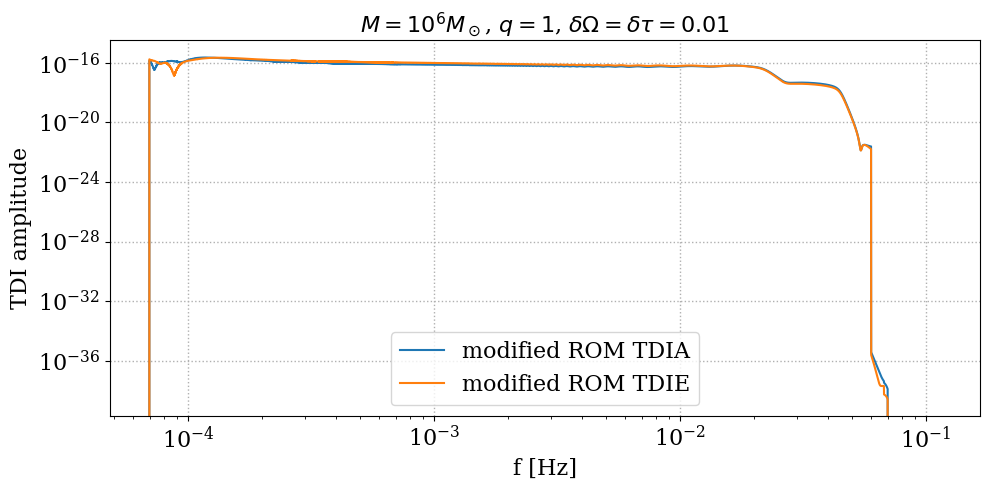

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q1/datalm_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q1_id_0.h5


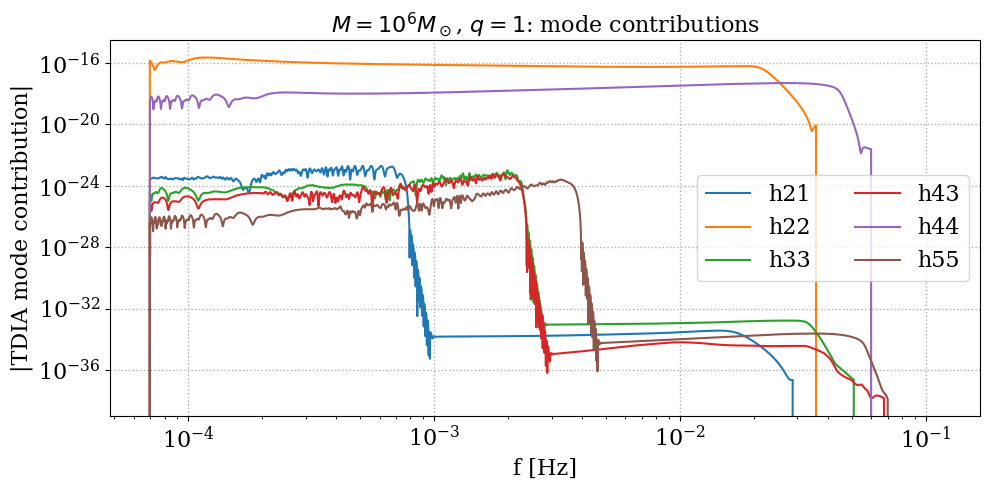

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q1/multiplier_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q1_id_0.h5


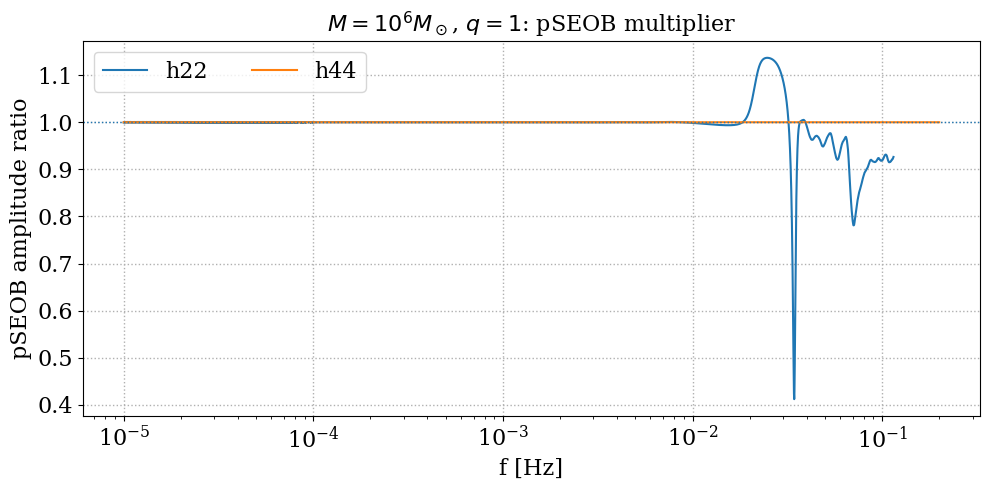


Inspecting M1e6, q2, id=1
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q2/data_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q2_id_1.h5
q: 2.0
d_omega: 0.01 d_tau: 0.01


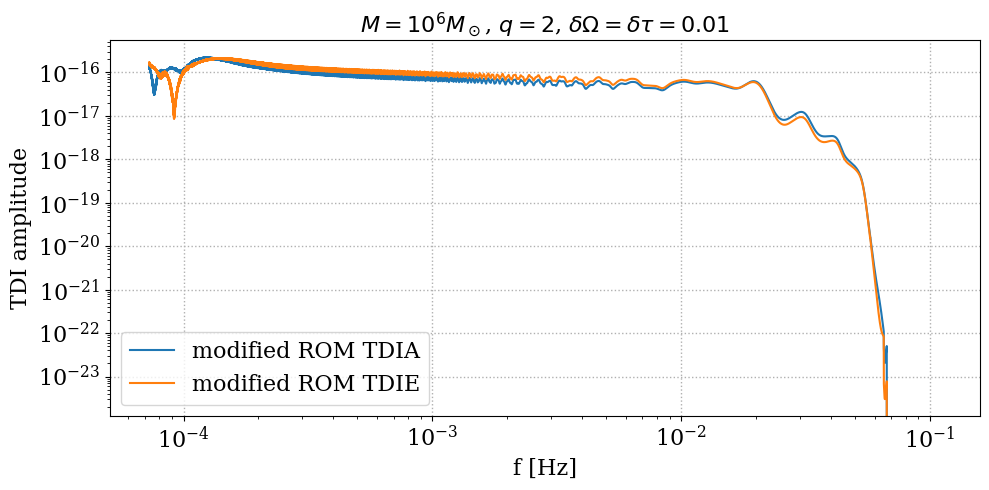

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q2/datalm_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q2_id_1.h5


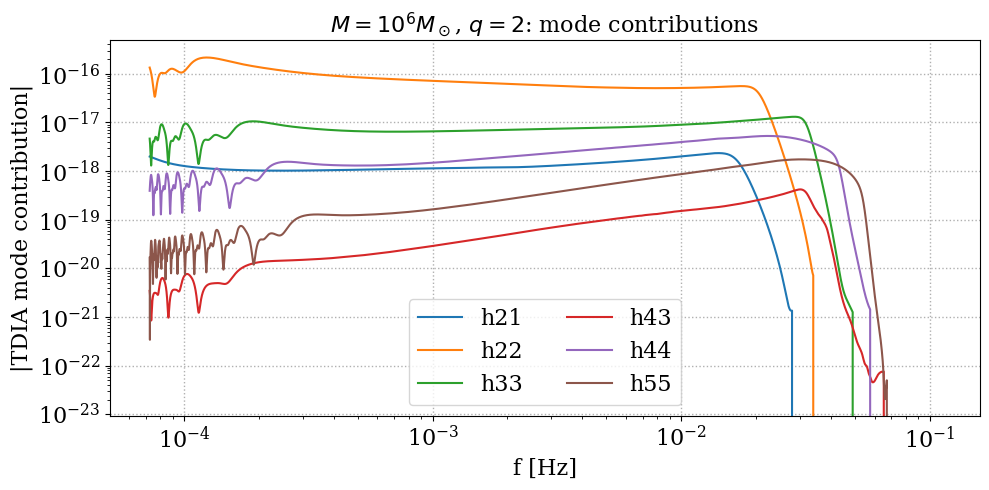

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q2/multiplier_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q2_id_1.h5


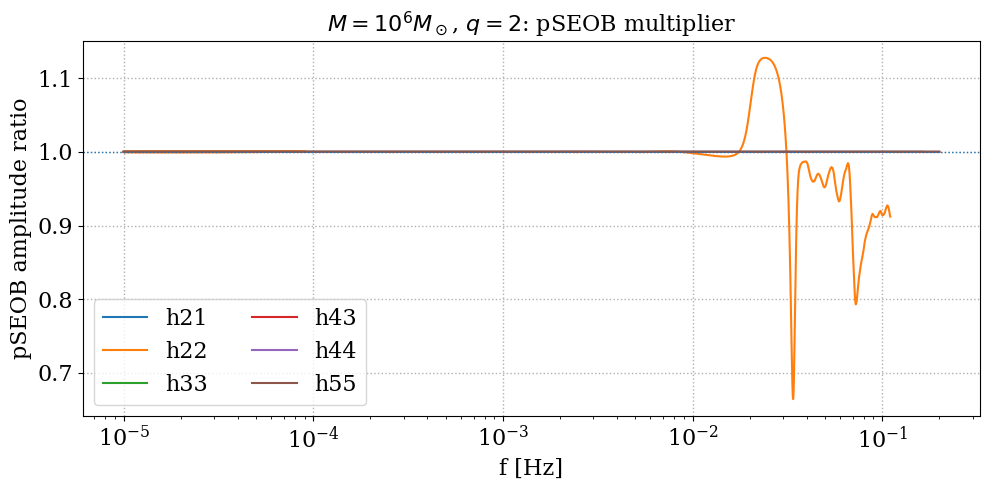


Inspecting M1e6, q3, id=2
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q3/data_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q3_id_2.h5
q: 3.0
d_omega: 0.01 d_tau: 0.01


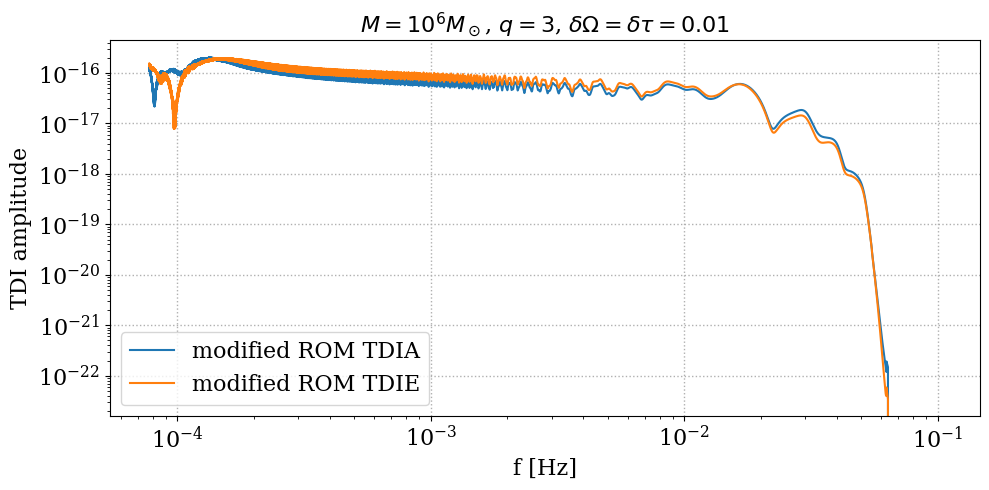

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q3/datalm_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q3_id_2.h5


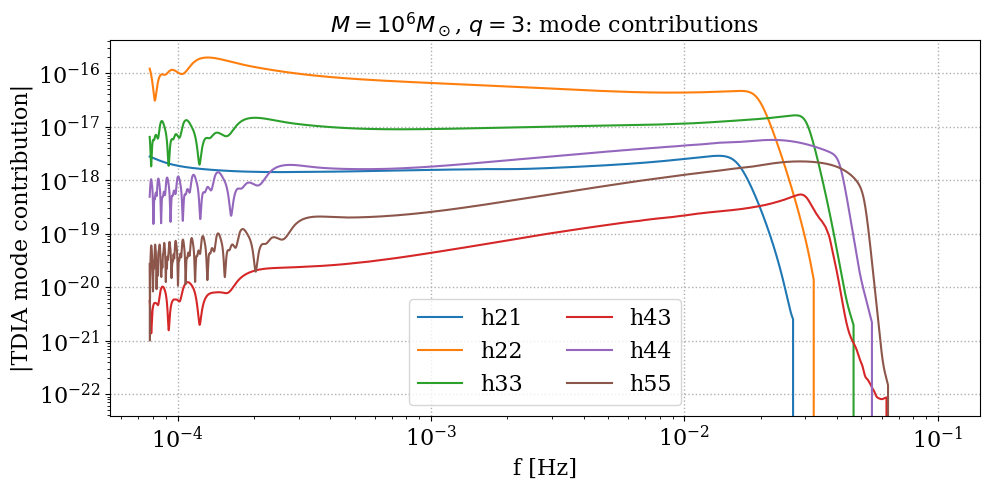

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q3/multiplier_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q3_id_2.h5


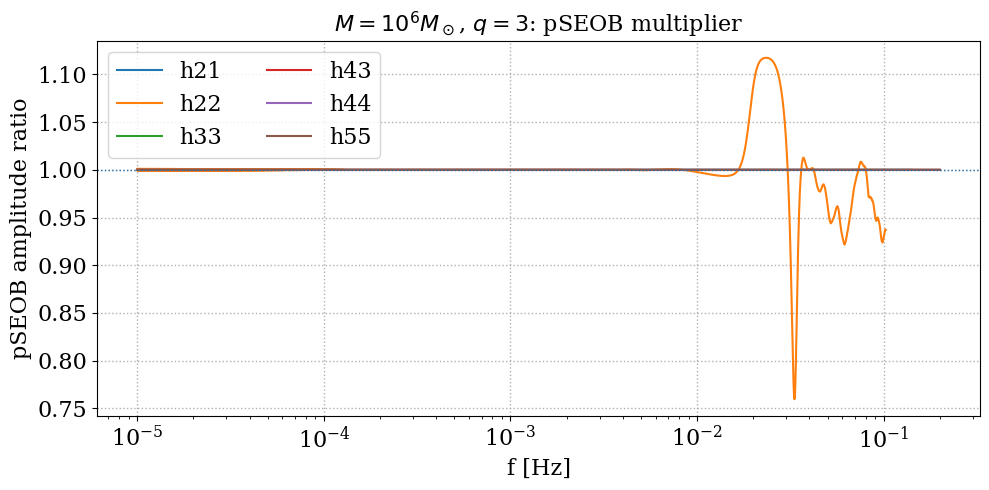


Inspecting M1e6, q4, id=3
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q4/data_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q4_id_3.h5
q: 4.0
d_omega: 0.01 d_tau: 0.01


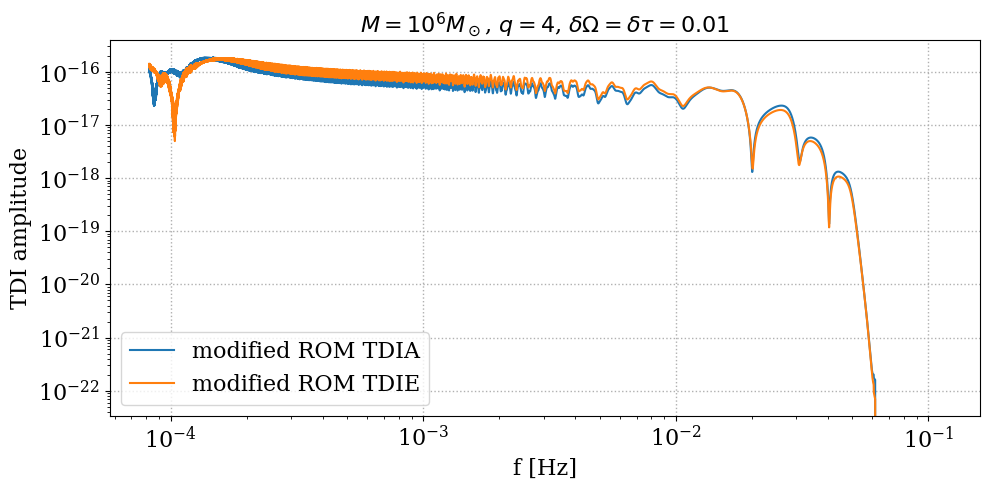

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q4/datalm_rom_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q4_id_3.h5


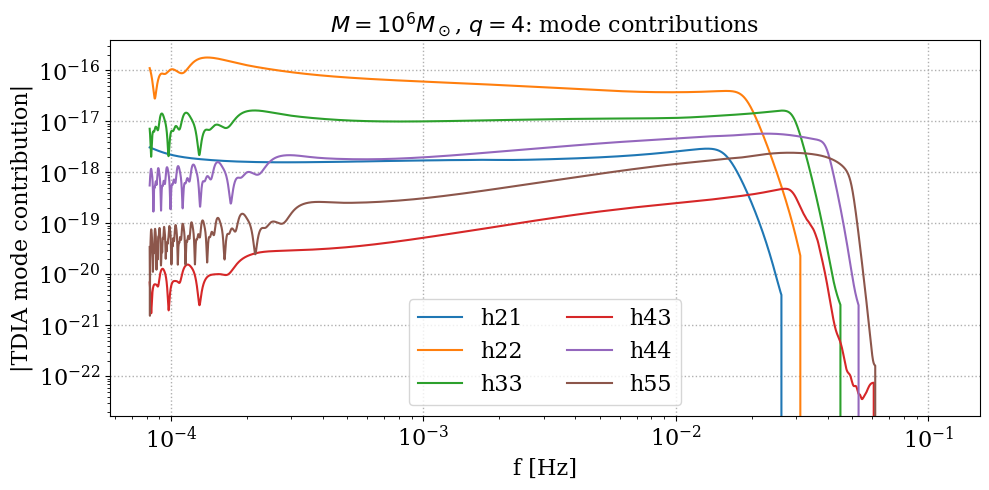

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/q4/multiplier_pseob_ratio_phase_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5_M1e6_q4_id_3.h5


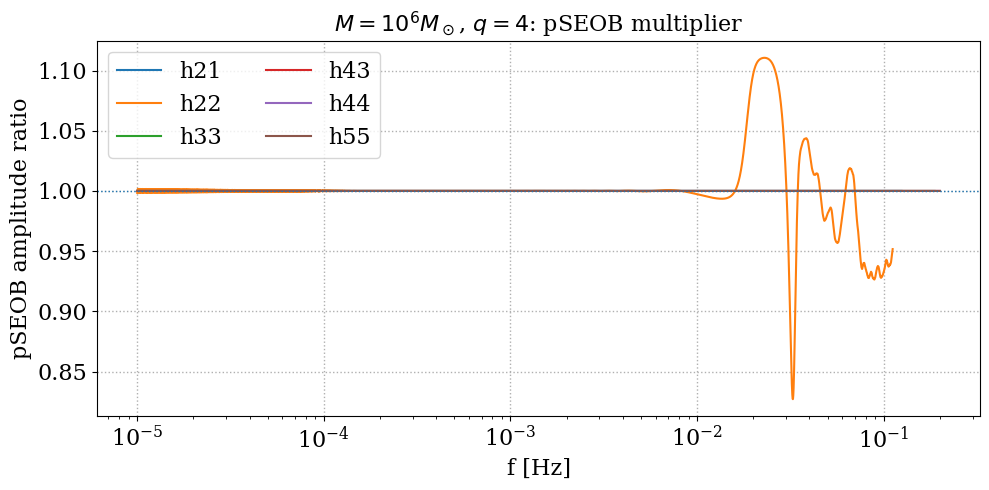

In [16]:
# Inspecting one saved waveform for every q value

for case_id, (q_value, q_label) in enumerate(zip(Q_VALUES, Q_LABELS)):
    print("\n" + "=" * 80)
    print(f"Inspecting {MASS_LABEL}, {q_label}, id={case_id}")

    data_file = os.path.join(
        Output_root,
        q_label,
        f"data_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )
    datalm_file = os.path.join(
        Output_root,
        q_label,
        f"datalm_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )
    multiplier_file = os.path.join(
        Output_root,
        q_label,
        f"multiplier_pseob_ratio_phase_{deviation_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )

    print("Reading:", data_file)
    with h5py.File(data_file, "r") as hf:
        data = {key: hf[key][:] for key in hf.keys()}
        print("q:", hf.attrs.get("q"))
        print("d_omega:", hf.attrs.get("d_omega"), "d_tau:", hf.attrs.get("d_tau"))

    plt.figure(figsize=(10, 5))
    plt.loglog(data["freq"], np.abs(data["TDIA"]), label="modified ROM TDIA")
    plt.loglog(data["freq"], np.abs(data["TDIE"]), label="modified ROM TDIE")
    plt.xlabel("f [Hz]")
    plt.ylabel("TDI amplitude")
    plt.title(
        rf"$M=10^6M_\odot$, $q={q_value:g}$, "
        rf"$\delta\Omega=\delta\tau={DEVIATION_VALUE:g}$"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Reading:", datalm_file)
    with h5py.File(datalm_file, "r") as hf:
        plt.figure(figsize=(10, 5))
        for group in hf.keys():
            freq = hf[group]["freq"][:]
            channel_a = hf[group]["TDIA"][:]
            plt.loglog(freq, np.abs(channel_a), label=group)
        plt.xlabel("f [Hz]")
        plt.ylabel("|TDIA mode contribution|")
        plt.title(rf"$M=10^6M_\odot$, $q={q_value:g}$: mode contributions")
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    print("Reading:", multiplier_file)
    with h5py.File(multiplier_file, "r") as hf:
        plt.figure(figsize=(10, 5))
        for group in hf.keys():
            freq = hf[group]["freq"][:]
            ratio = hf[group]["amp_ratio"][:]
            plt.semilogx(freq, ratio, label=group)
        plt.axhline(1.0, linestyle=":", linewidth=1)
        plt.xlabel("f [Hz]")
        plt.ylabel("pSEOB amplitude ratio")
        plt.title(rf"$M=10^6M_\odot$, $q={q_value:g}$: pSEOB multiplier")
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()


## 9. Comparing the full mass-ratio scan




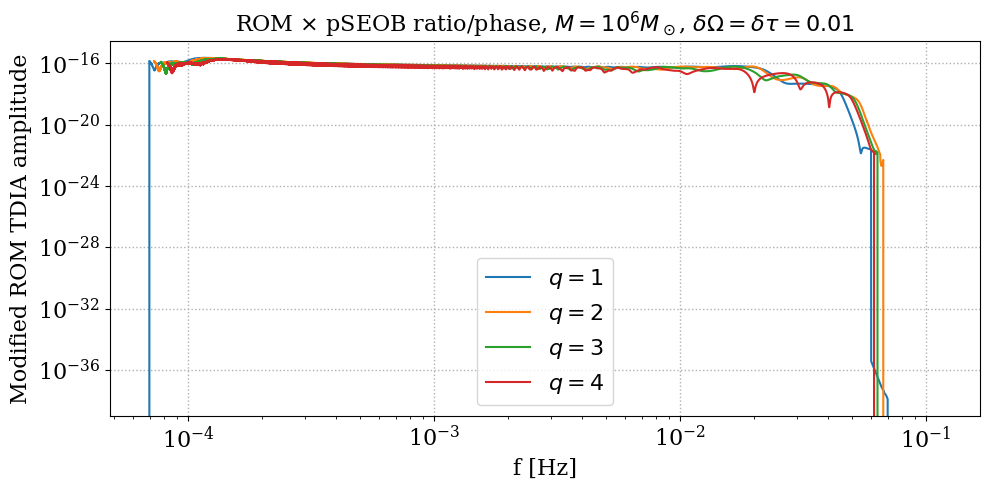

In [17]:
# Comparing total TDIA amplitudes across all five mass ratios

plt.figure(figsize=(10, 5))

for case_id, (q_value, q_label) in enumerate(zip(Q_VALUES, Q_LABELS)):
    data_file = os.path.join(
        Output_root,
        q_label,
        f"data_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )
    if not os.path.exists(data_file):
        print("Missing:", data_file)
        continue

    with h5py.File(data_file, "r") as hf:
        freq = hf["freq"][:]
        channel_a = hf["TDIA"][:]
        q_file = float(hf.attrs.get("q", q_value))

    plt.loglog(freq, np.abs(channel_a), label=rf"$q={q_file:g}$")

plt.xlabel("f [Hz]")
plt.ylabel("Modified ROM TDIA amplitude")
plt.title(
    rf"ROM $\times$ pSEOB ratio/phase, $M=10^6M_\odot$, "
    rf"$\delta\Omega=\delta\tau={DEVIATION_VALUE:g}$"
)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Consistency checks for all five mass ratios

Check parameter labels, saved file shapes, mode sums, and the applied multipliers for every q.


In [18]:
import pandas as pd


def prepare_consistency_case(q_value, q_label, case_id):
    """Loading one saved q case and rebuilding its ordinary ROM waveform."""
    params_file = create_or_load_scan_params_file()
    params_check = load_injection_params(params_file, case_id=case_id)

    out_dir = os.path.join(Output_root, q_label)
    data_file = os.path.join(
        out_dir,
        f"data_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )
    datalm_file = os.path.join(
        out_dir,
        f"datalm_{output_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )
    multiplier_file = os.path.join(
        out_dir,
        f"multiplier_pseob_ratio_phase_{deviation_tag}_{MASS_LABEL}_{q_label}_id_{case_id}.h5",
    )

    for file_path in (data_file, datalm_file, multiplier_file):
        if not os.path.exists(file_path):
            raise FileNotFoundError(file_path)

    with h5py.File(data_file, "r") as hf:
        freq_grid = hf["freq"][:]
        modified_tdi = {
            "freq": freq_grid.copy(),
            "TDIA": hf["TDIA"][:],
            "TDIE": hf["TDIE"][:],
        }
        saved_mass = float(hf.attrs.get("M", params_check["M"]))
        saved_q = float(hf.attrs.get("q", params_check["q"]))
        saved_domega = float(hf.attrs.get("d_omega", params_check["d_omega"]))
        saved_dtau = float(hf.attrs.get("d_tau", params_check["d_tau"]))

    expected = {
        "M": (saved_mass, MASS_VALUE),
        "q": (saved_q, q_value),
        "d_omega": (saved_domega, DEVIATION_VALUE),
        "d_tau": (saved_dtau, DEVIATION_VALUE),
    }
    for name, (stored, requested) in expected.items():
        if not np.isclose(stored, requested):
            raise ValueError(
                f"{name} mismatch for {q_label}: expected {requested}, found {stored}"
            )

    modified_modes = {}
    with h5py.File(datalm_file, "r") as hf:
        for lm in common_modes:
            group = f"h{lm[0]}{lm[1]}"
            if group not in hf:
                continue
            modified_modes[lm] = {
                "freq": hf[group]["freq"][:],
                "TDIA": hf[group]["TDIA"][:],
                "TDIE": hf[group]["TDIE"][:],
            }

    tdifreqseries_rom = generate_rom_tdi_modes(
        params_check,
        freq_grid,
        waveform_params=waveform_params_rom,
    )

    rom_tdi = {
        "freq": freq_grid.copy(),
        "TDIA": np.zeros_like(freq_grid, dtype=complex),
        "TDIE": np.zeros_like(freq_grid, dtype=complex),
    }
    rom_modes = {}

    for lm in common_modes:
        if lm not in tdifreqseries_rom:
            continue

        rom_a = np.asarray(tdifreqseries_rom[lm]["chan1"])
        rom_e = np.asarray(tdifreqseries_rom[lm]["chan2"])

        if rom_a.shape != freq_grid.shape or rom_e.shape != freq_grid.shape:
            raise ValueError(f"ROM shape mismatch for {q_label}, mode {lm}")

        rom_modes[lm] = {
            "freq": freq_grid.copy(),
            "TDIA": rom_a,
            "TDIE": rom_e,
        }
        rom_tdi["TDIA"] += rom_a
        rom_tdi["TDIE"] += rom_e

    return {
        "mass_value": MASS_VALUE,
        "mass_label": MASS_LABEL,
        "q_value": float(q_value),
        "q_label": q_label,
        "case_id": case_id,
        "params": params_check,
        "multiplier_file": multiplier_file,
        "modified_tdi": modified_tdi,
        "modified_modes": modified_modes,
        "rom_tdi": rom_tdi,
        "rom_modes": rom_modes,
    }


consistency_cases = {
    q_label: prepare_consistency_case(q_value, q_label, case_id)
    for case_id, (q_value, q_label) in enumerate(zip(Q_VALUES, Q_LABELS))
}

for q_label, case in consistency_cases.items():
    print("\n" + "=" * 80)
    print("q_label =", q_label)
    print("M =", case["params"]["M"])
    print("q =", case["params"]["q"])
    print("case_id =", case["case_id"])
    print("d_omega =", case["params"]["d_omega"])
    print("d_tau =", case["params"]["d_tau"])
    print("ROM modes:", list(case["rom_modes"].keys()))
    print("Modified modes:", list(case["modified_modes"].keys()))


Using existing q-scan parameter file: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5.h5
Using existing q-scan parameter file: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5.h5
Using existing q-scan parameter file: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5.h5
Using existing q-scan parameter file: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Mass_ratio/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5/params_injection_set_domega_dtau_0p01_M1e6_q1_q2_q3_q4_q5

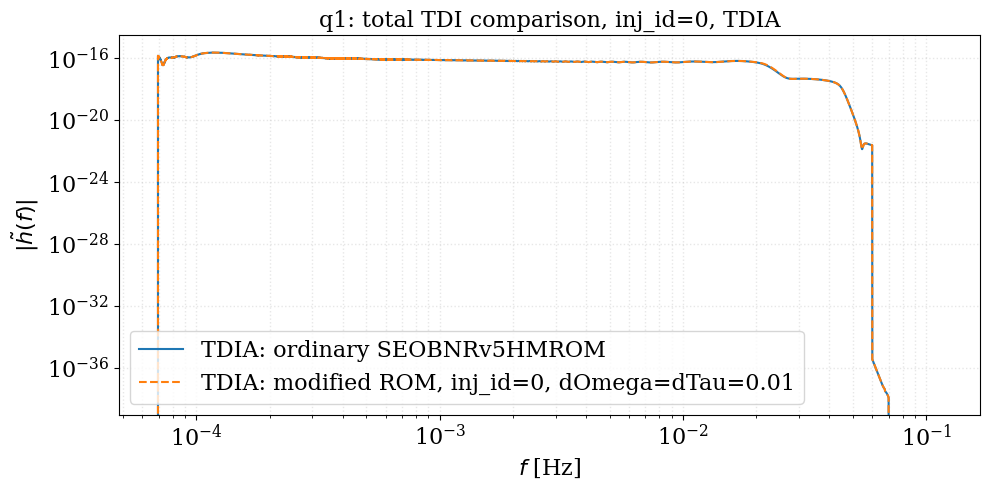

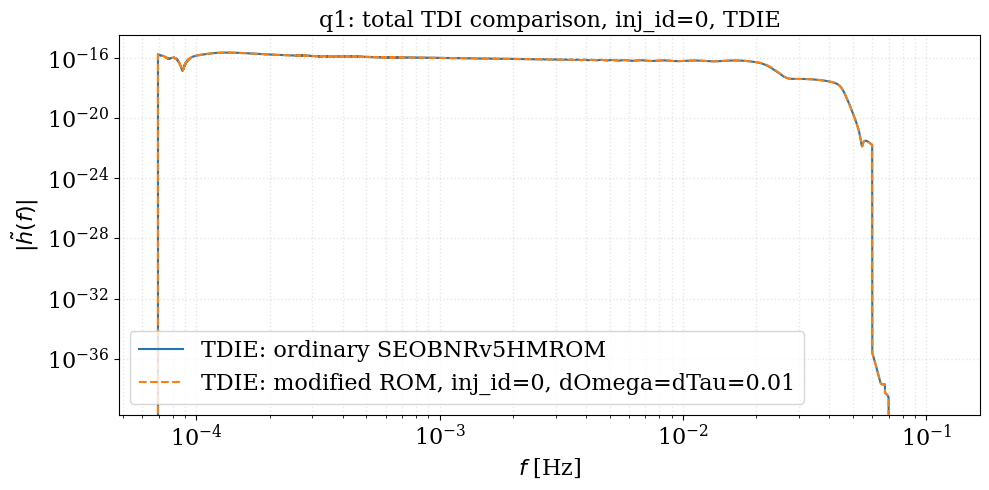

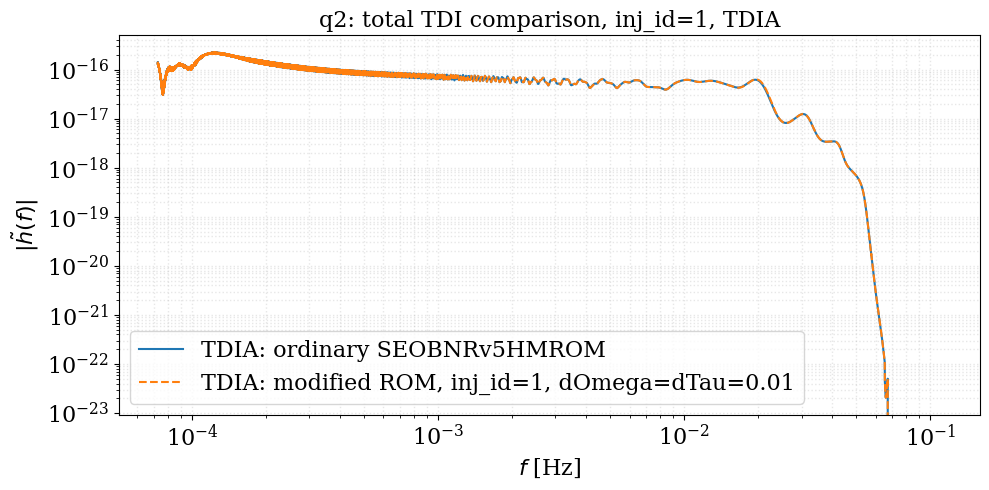

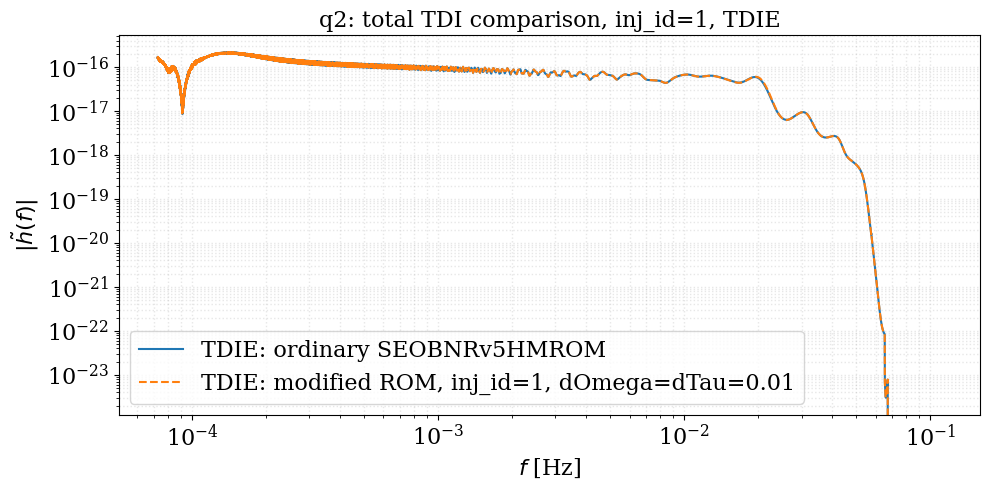

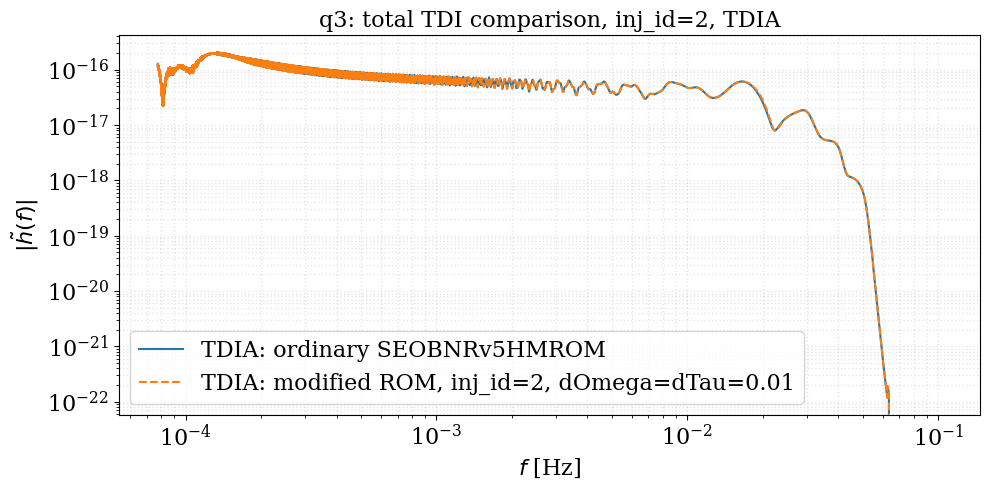

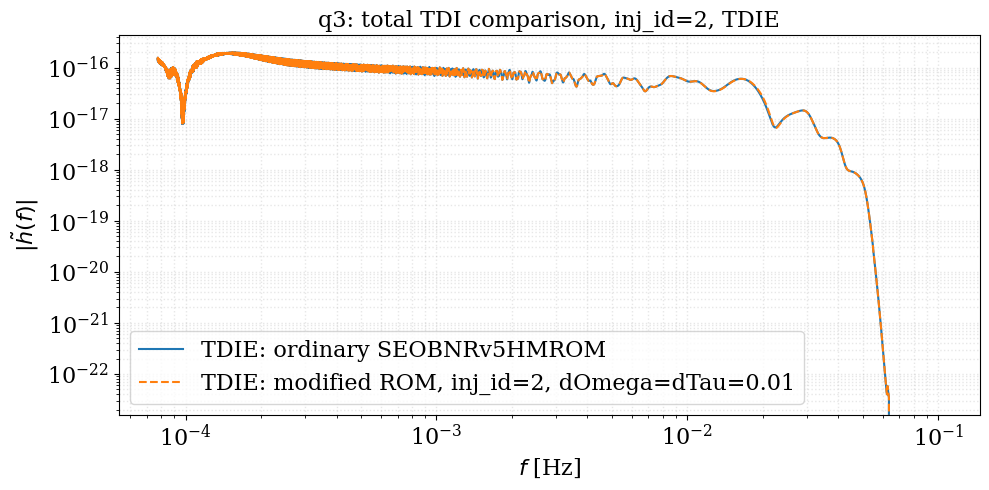

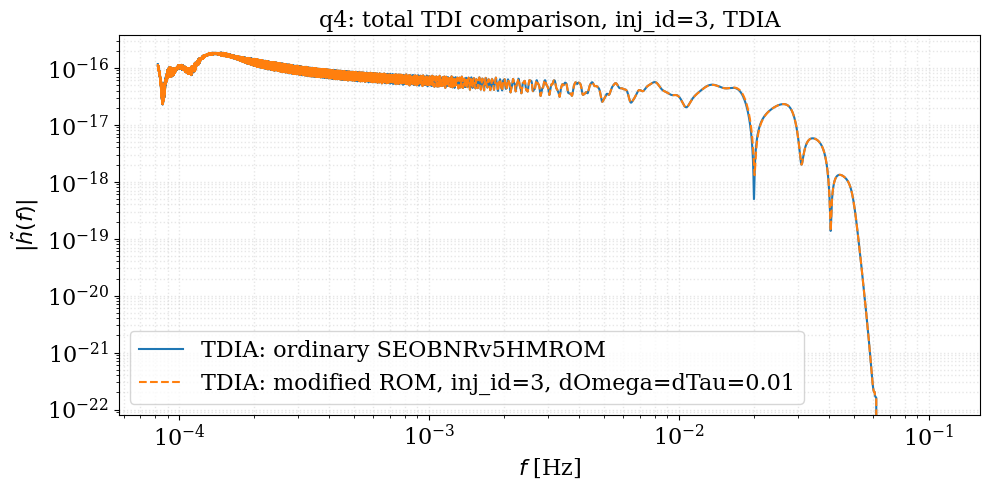

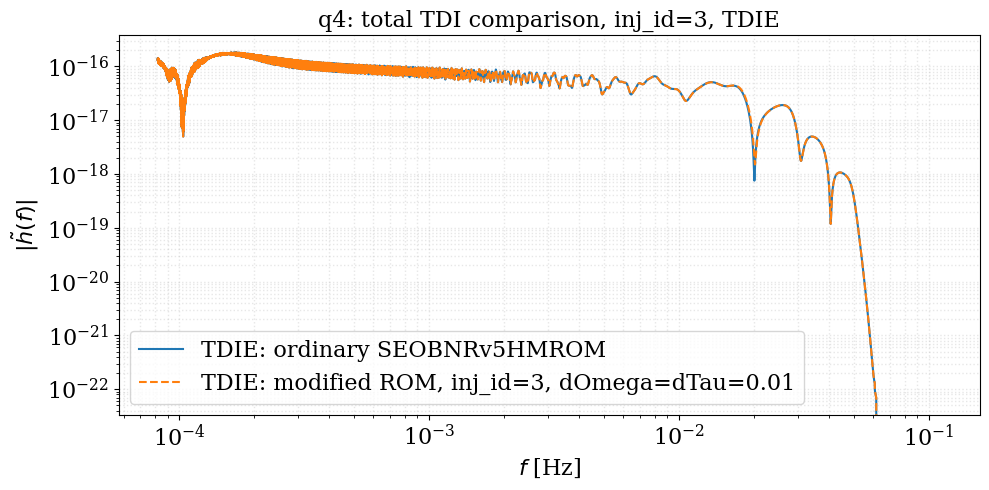

In [19]:
for q_label, case in consistency_cases.items():
    for channel in ("TDIA", "TDIE"):
        plt.figure(figsize=(10, 5))
        plt.loglog(
            case["rom_tdi"]["freq"],
            np.abs(case["rom_tdi"][channel]),
            label=f"{channel}: ordinary SEOBNRv5HMROM",
        )
        plt.loglog(
            case["modified_tdi"]["freq"],
            np.abs(case["modified_tdi"][channel]),
            "--",
            label=(
                f"{channel}: modified ROM, inj_id={case['case_id']}, "
                f"dOmega=dTau={case['params']['d_omega']:g}"
            ),
        )
        plt.xlabel(r"$f$ [Hz]")
        plt.ylabel(r"$|\tilde{h}(f)|$")
        plt.title(
            f"{q_label}: total TDI comparison, "
            f"inj_id={case['case_id']}, {channel}"
        )
        plt.legend()
        plt.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()


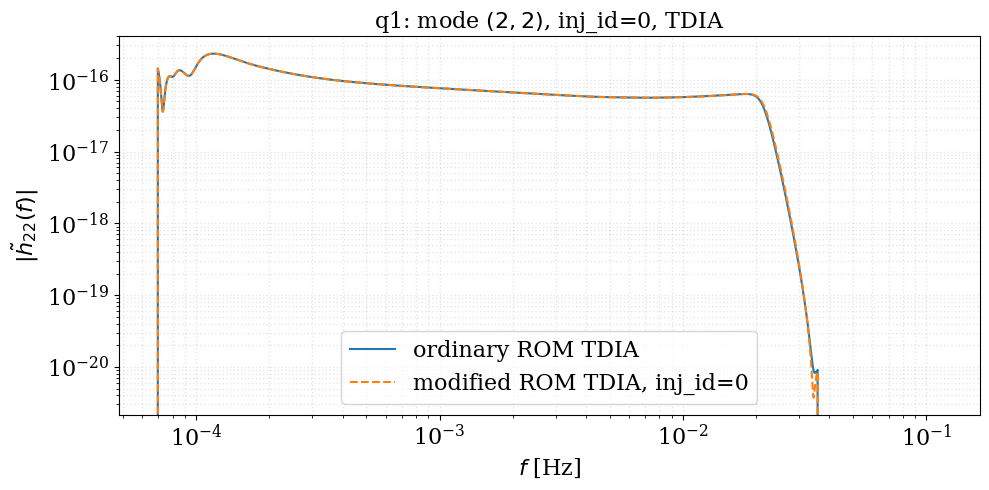

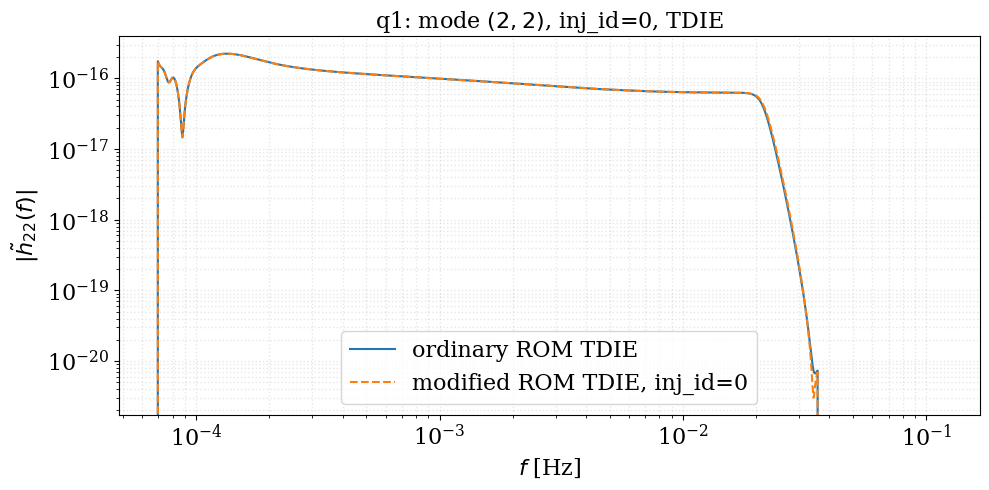

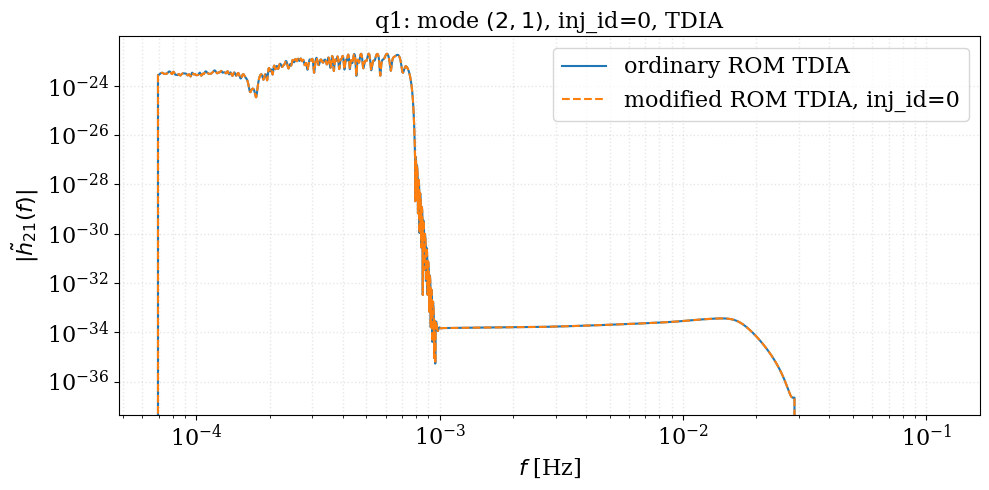

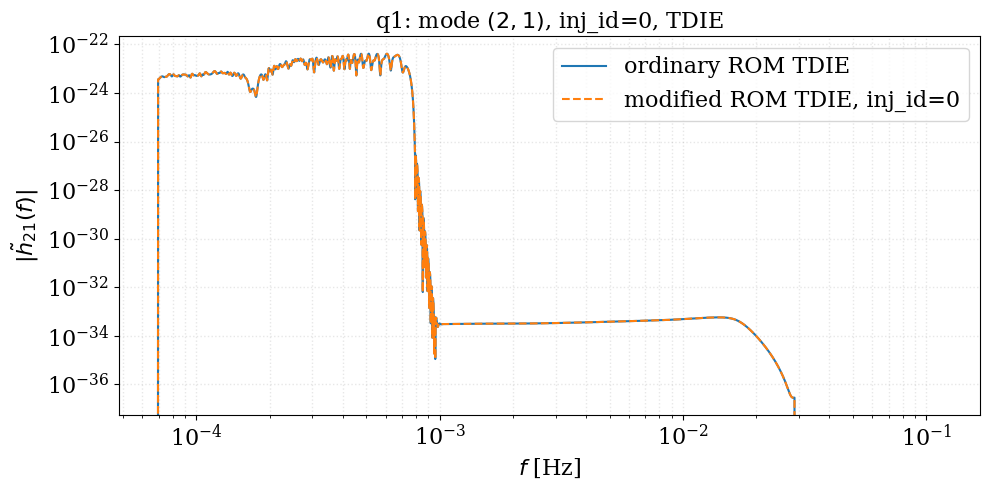

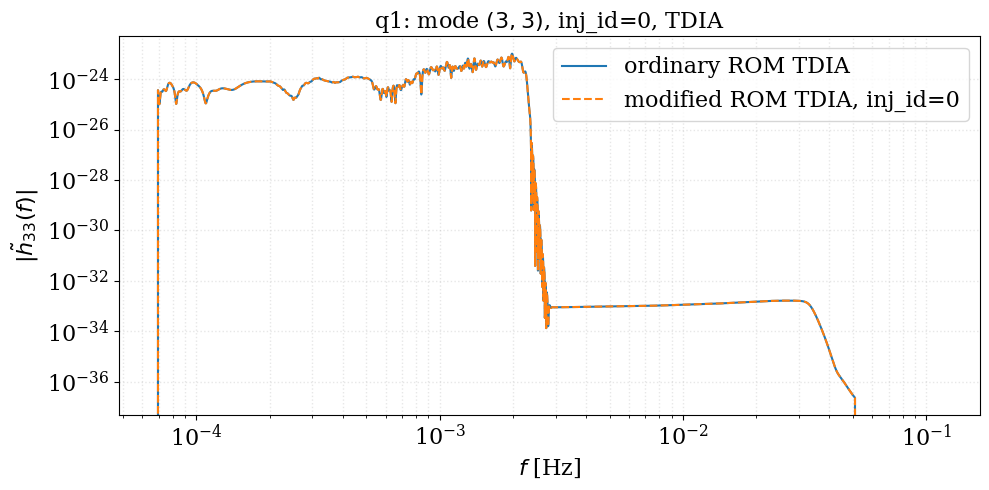

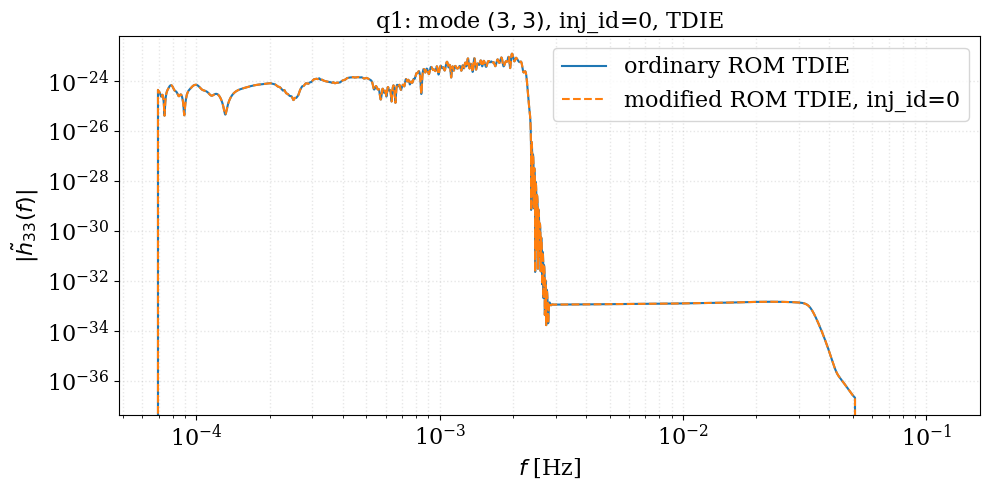

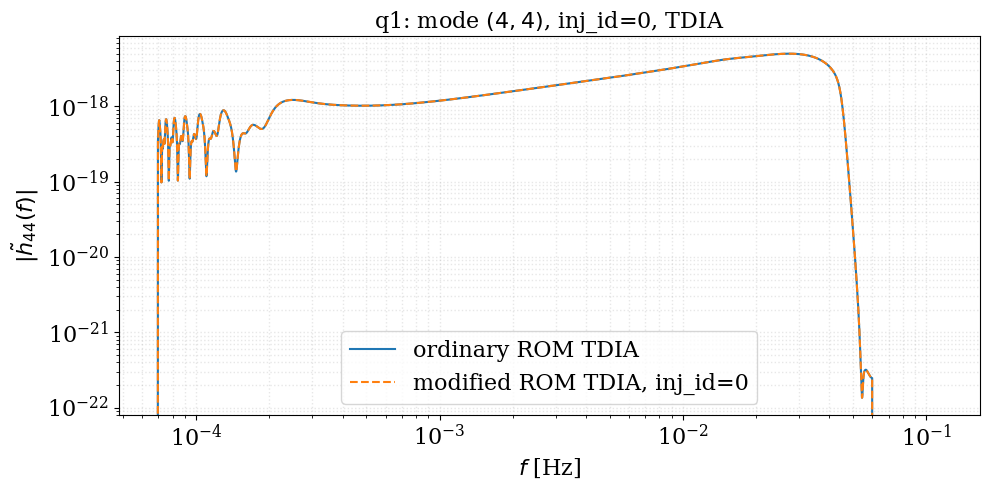

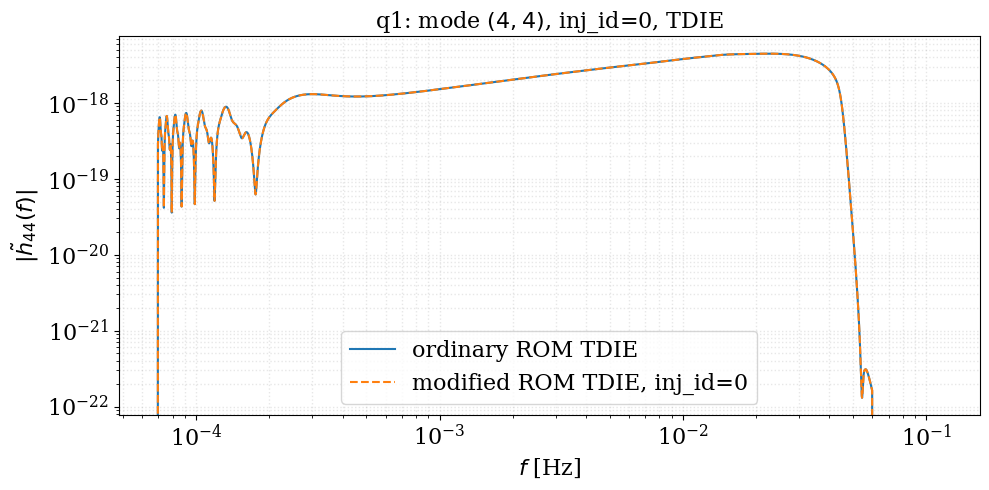

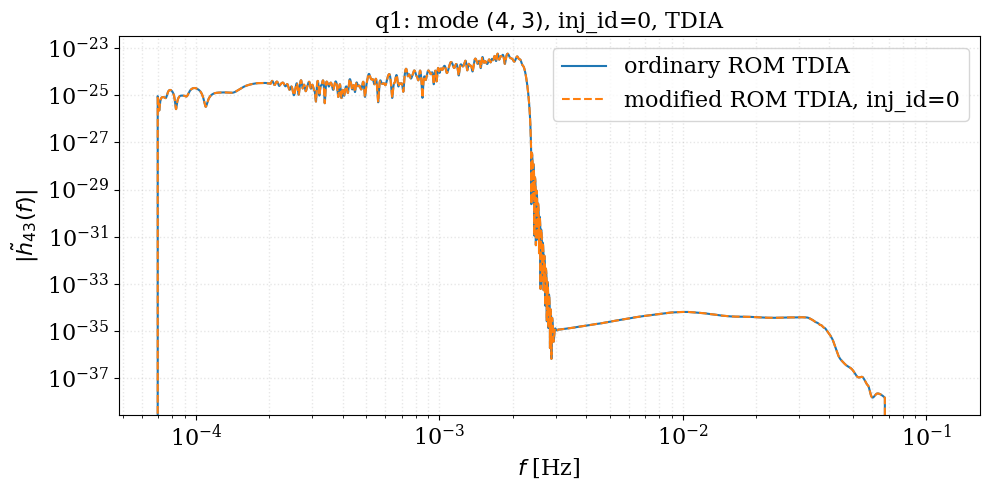

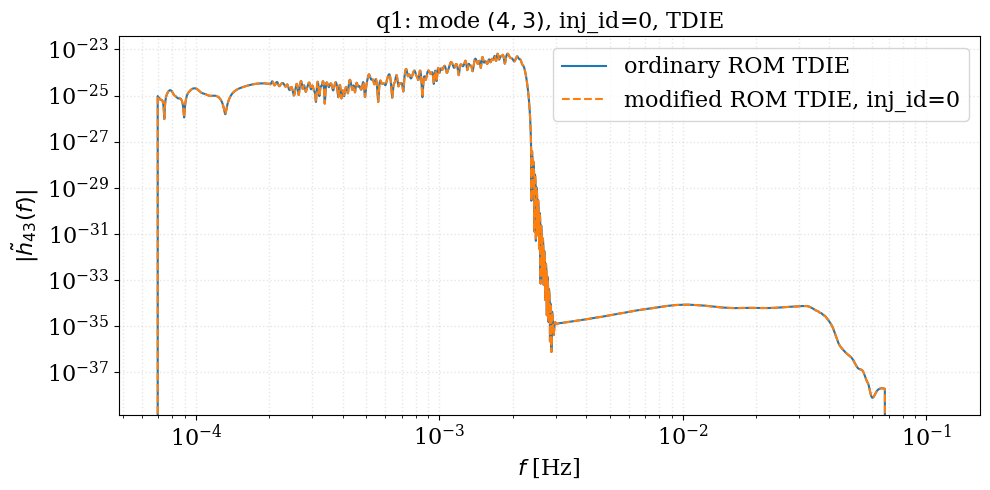

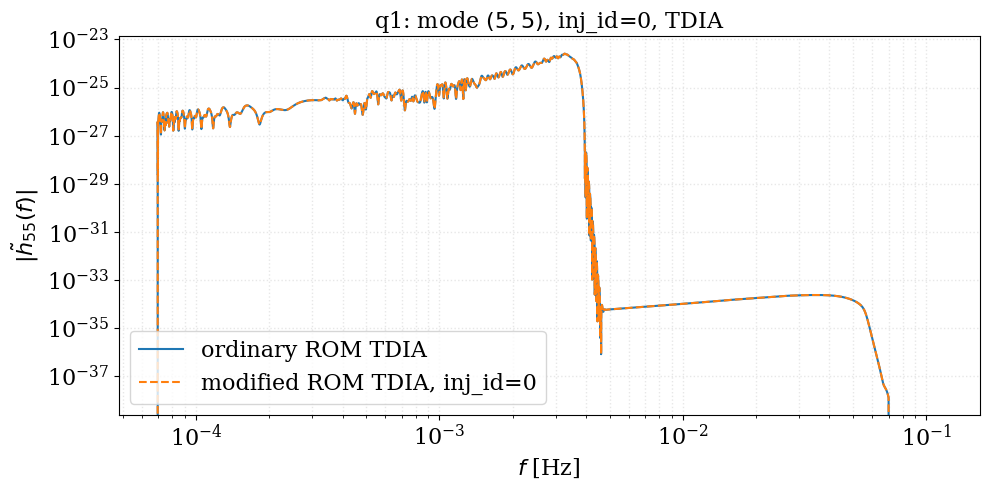

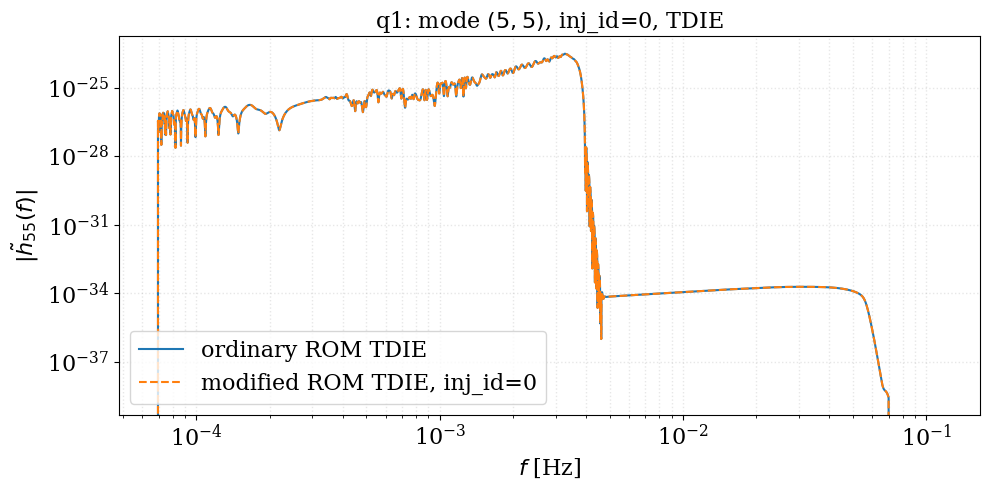

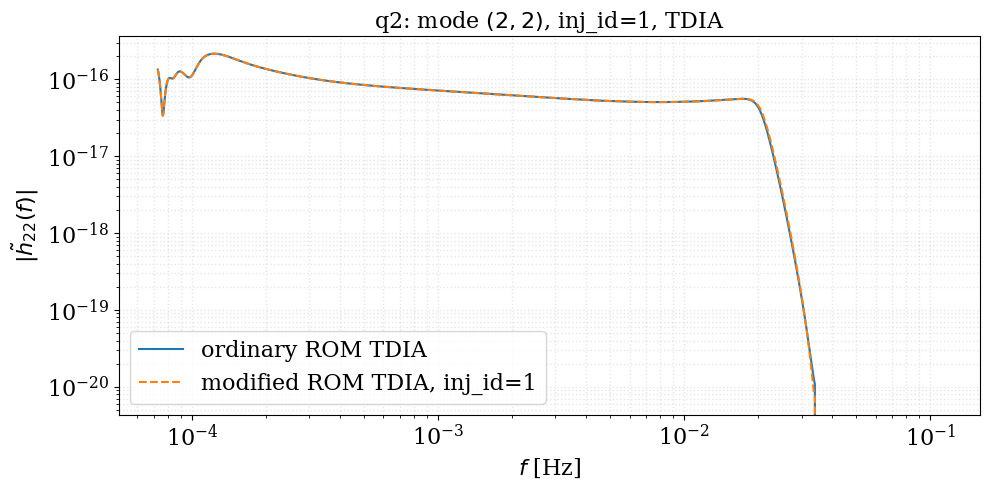

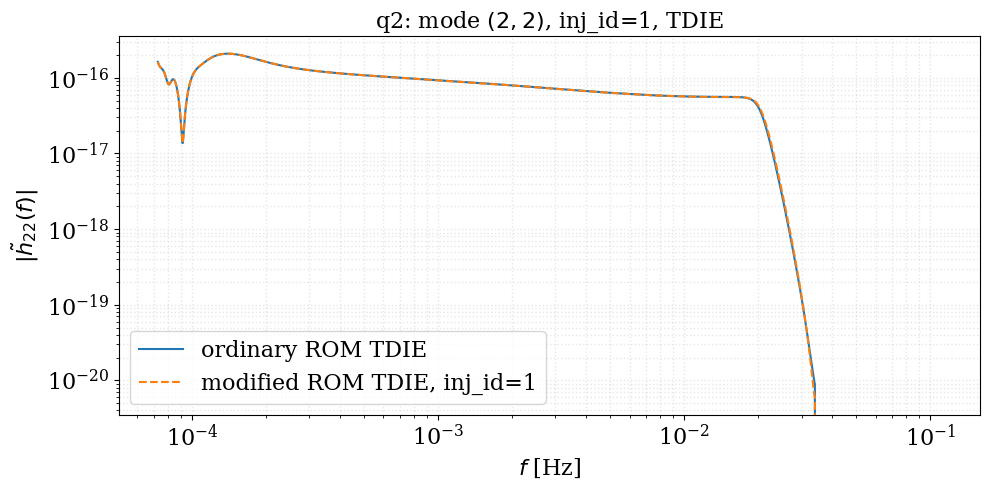

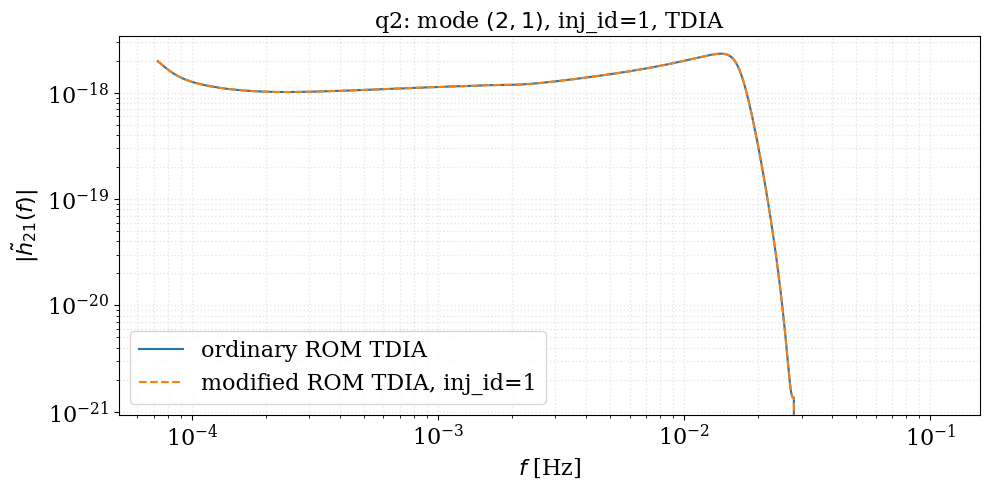

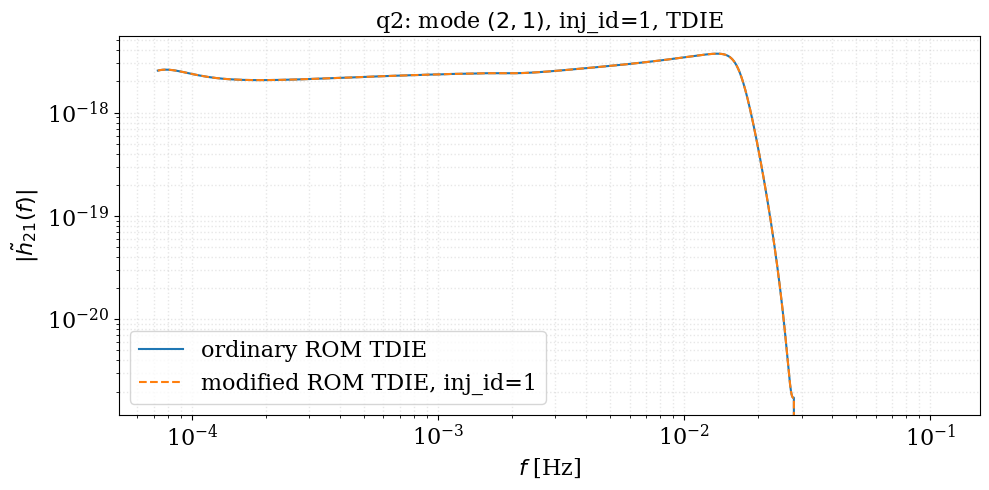

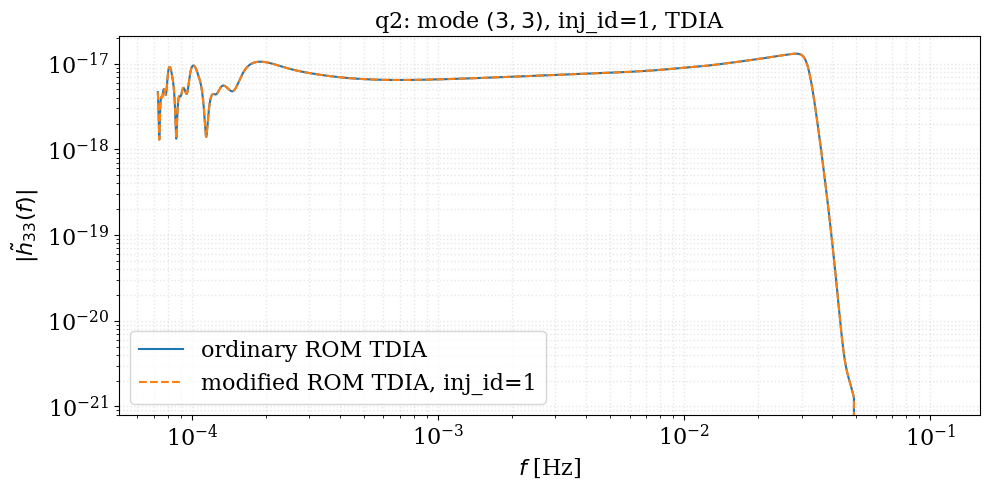

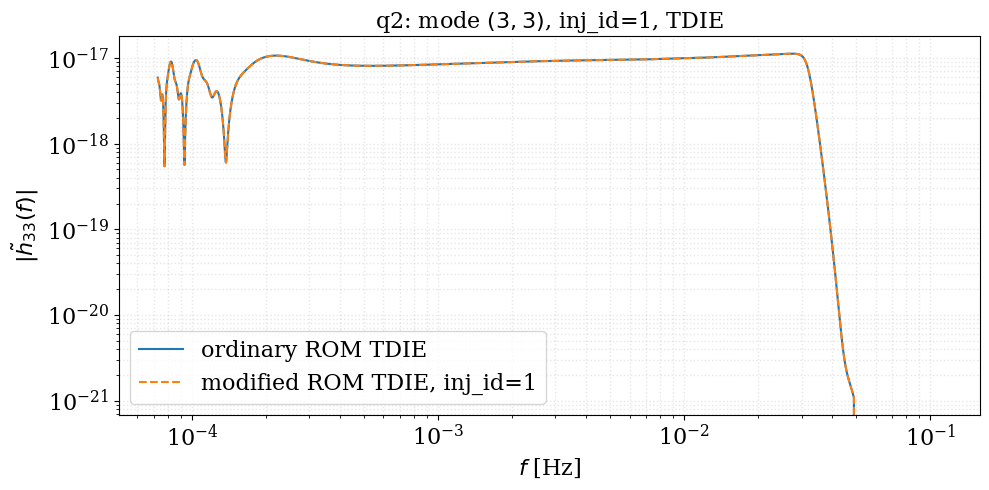

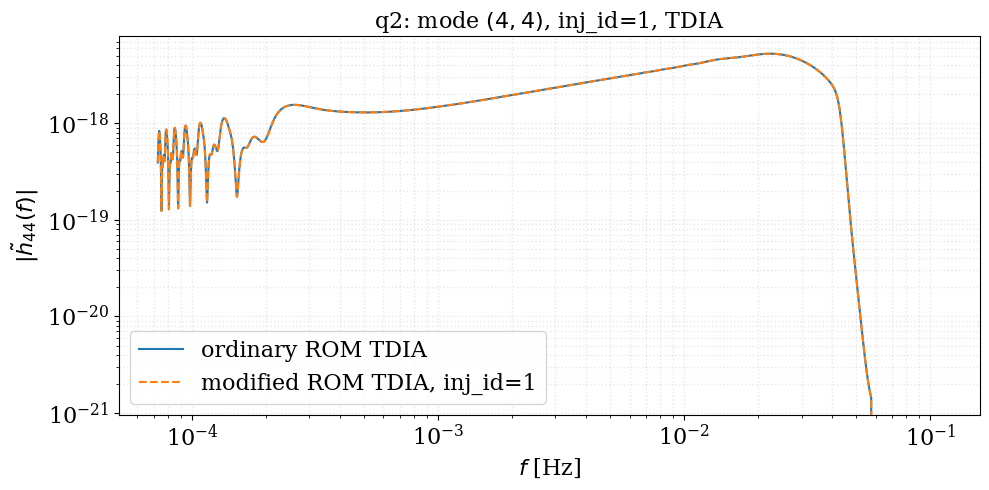

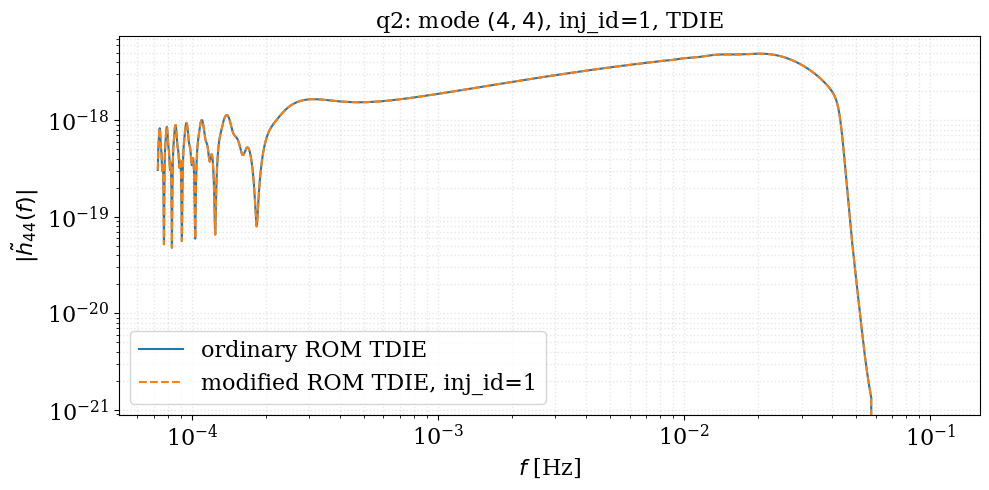

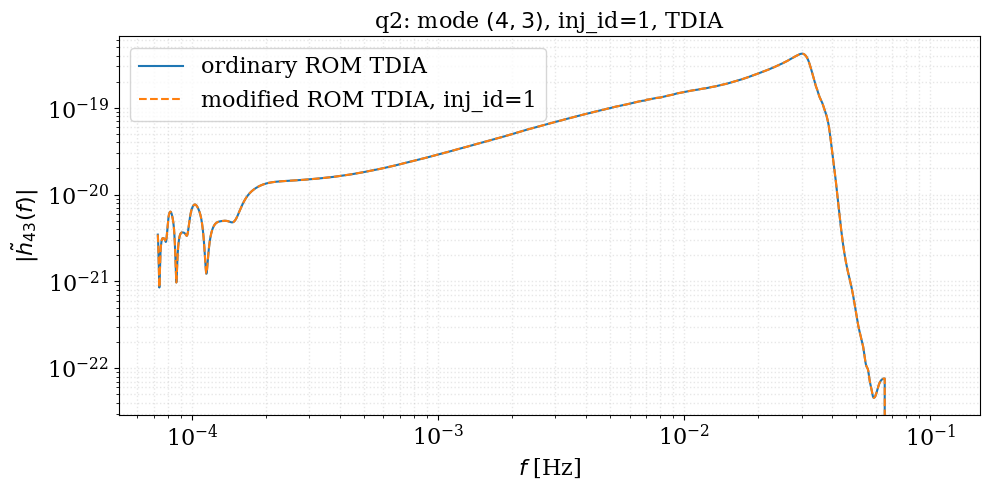

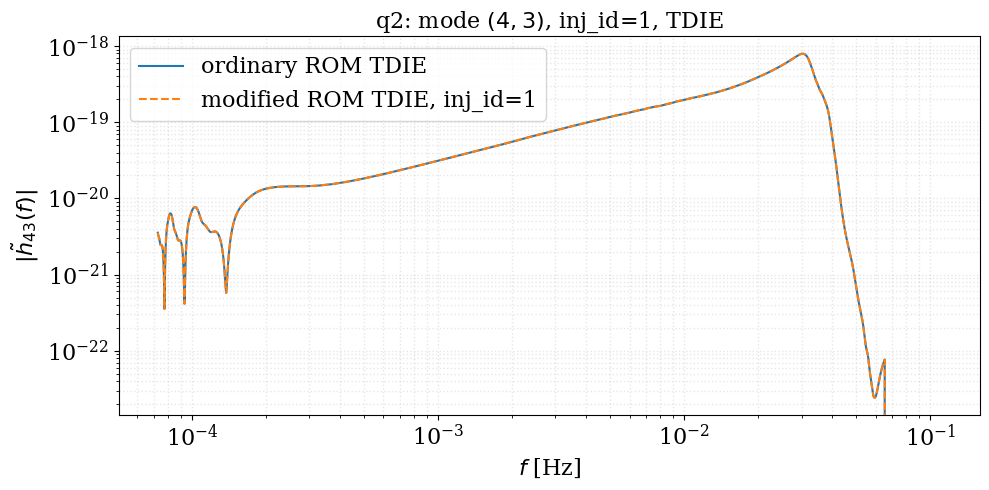

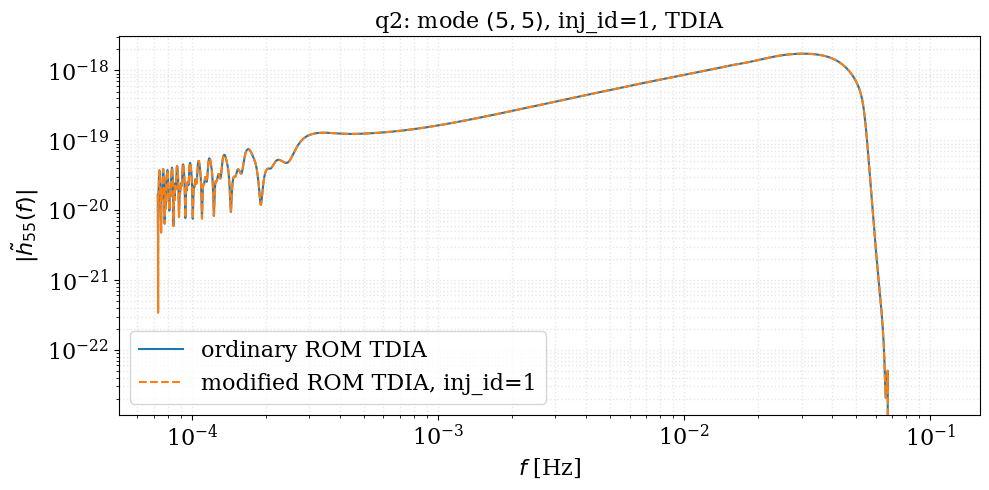

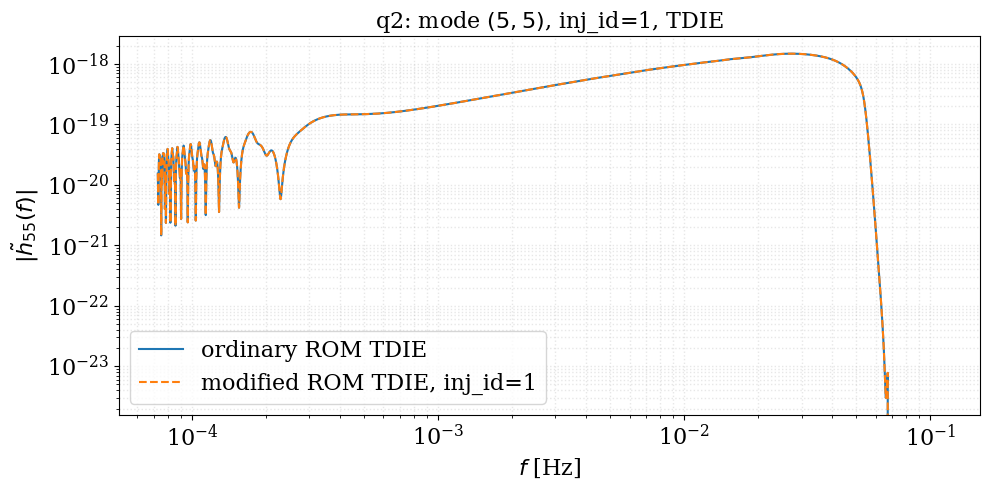

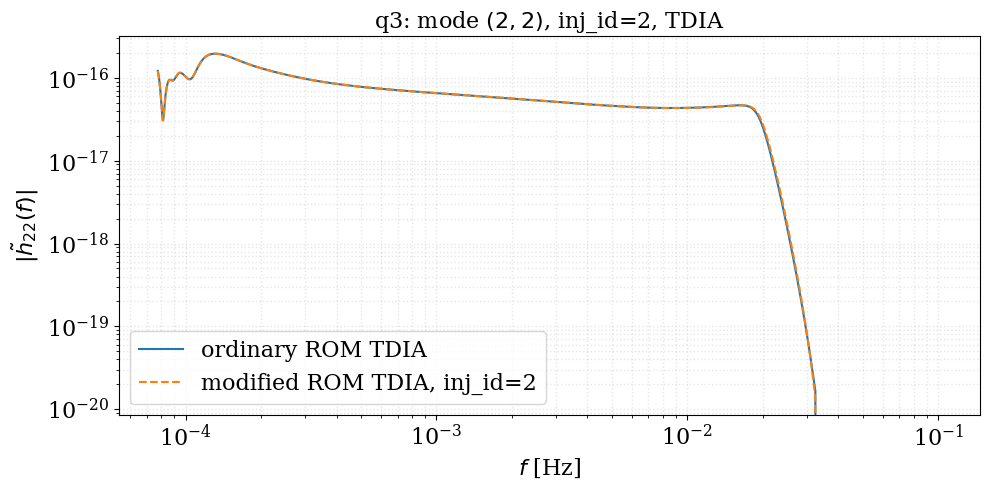

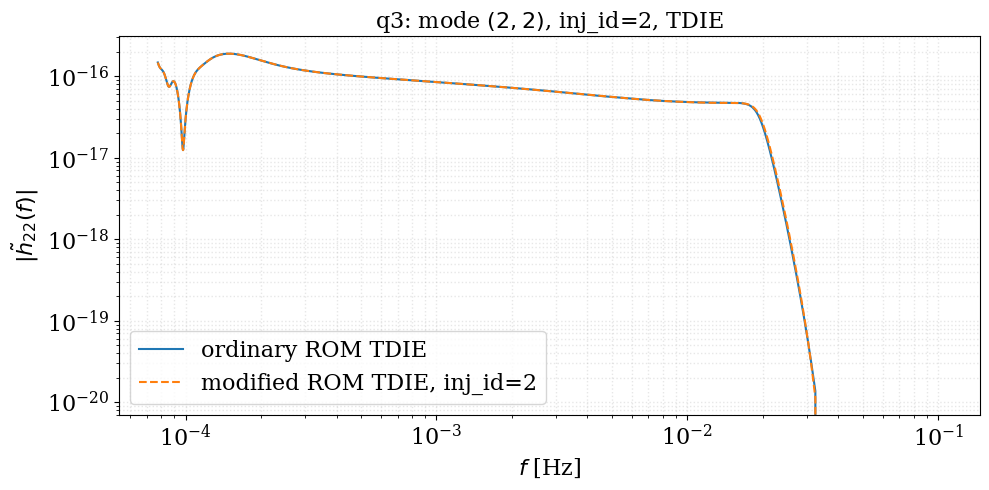

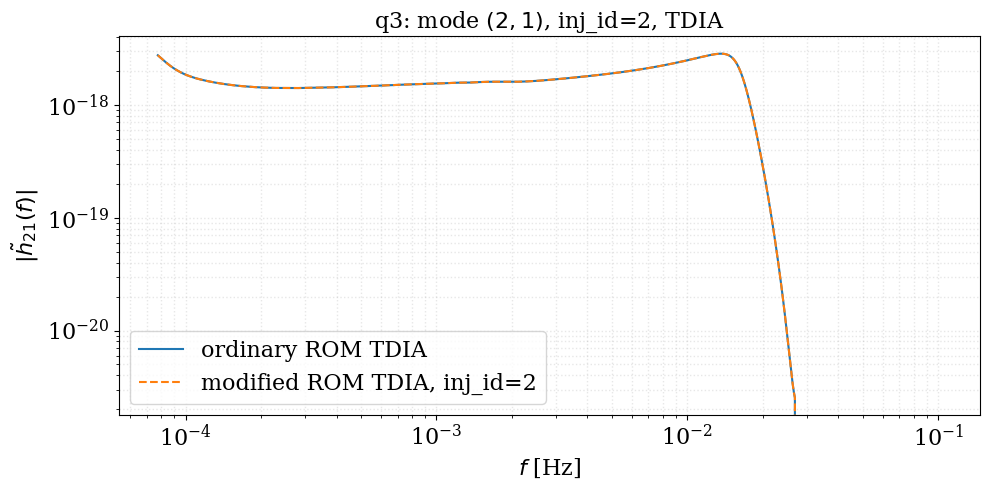

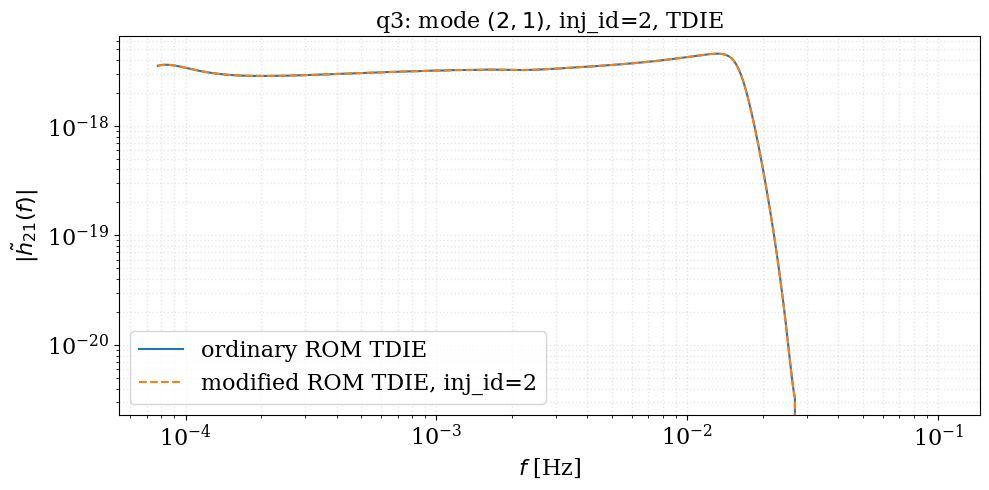

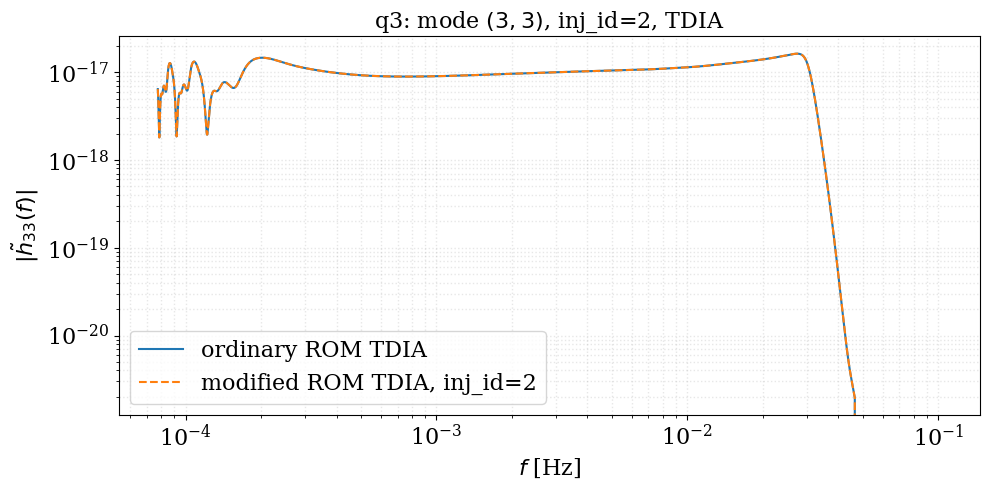

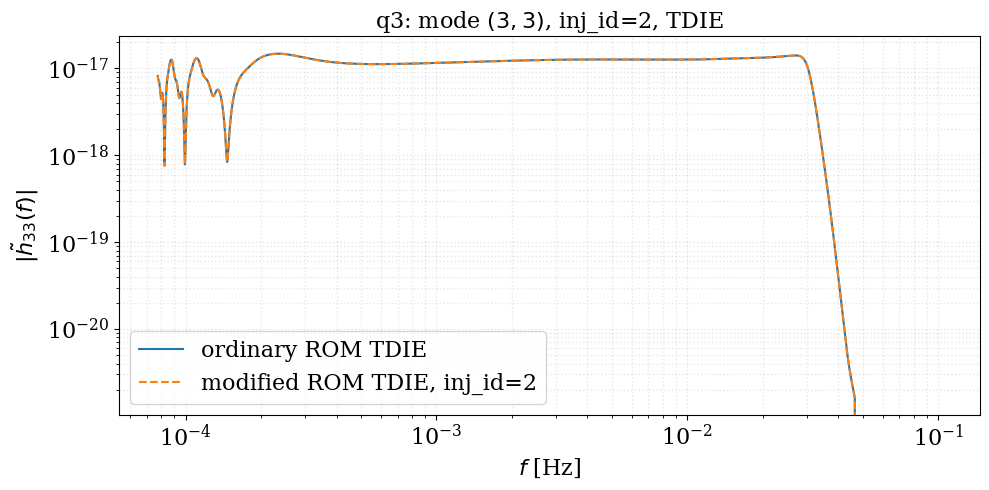

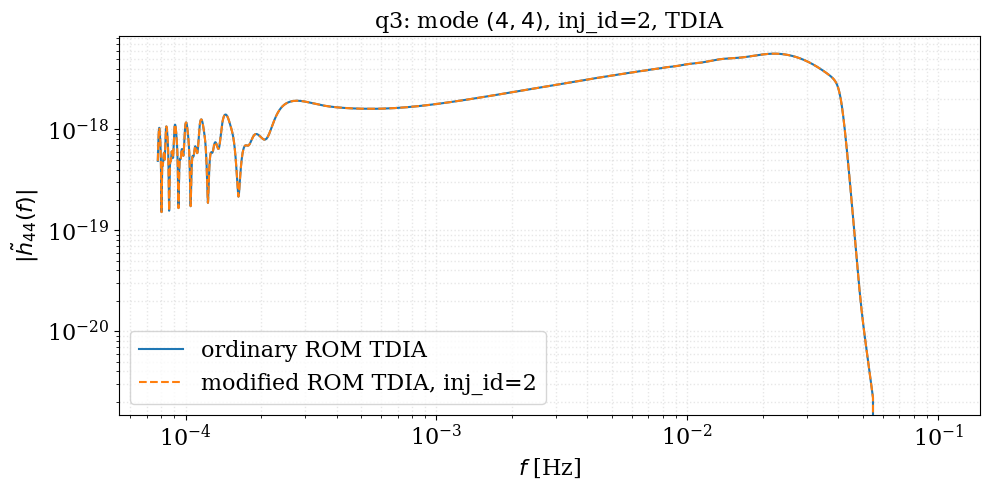

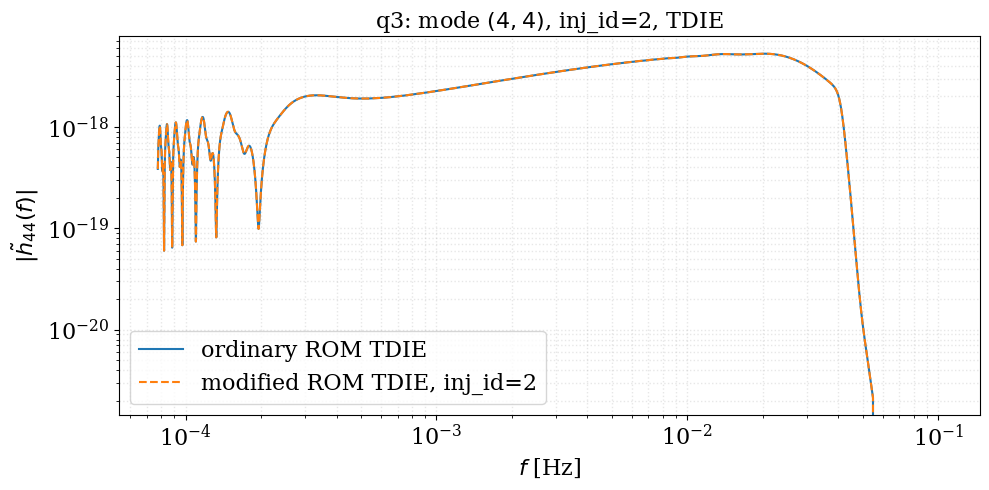

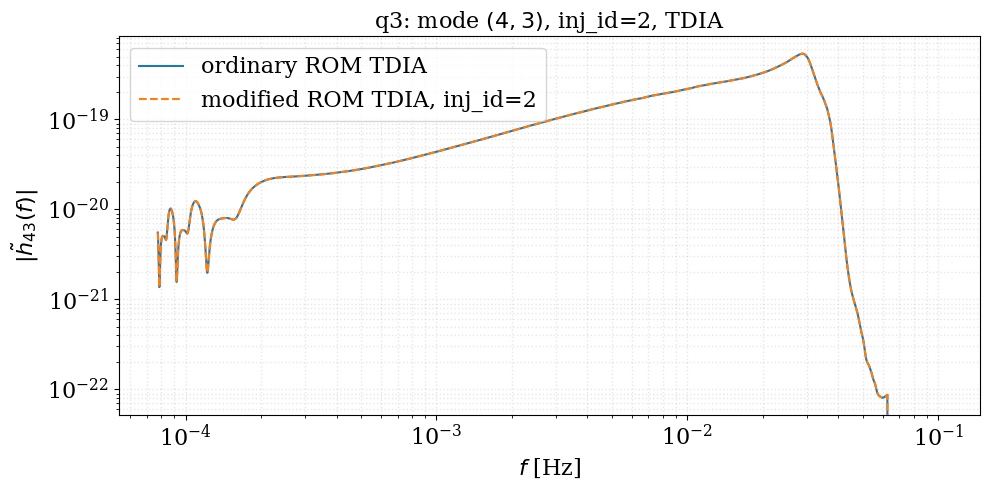

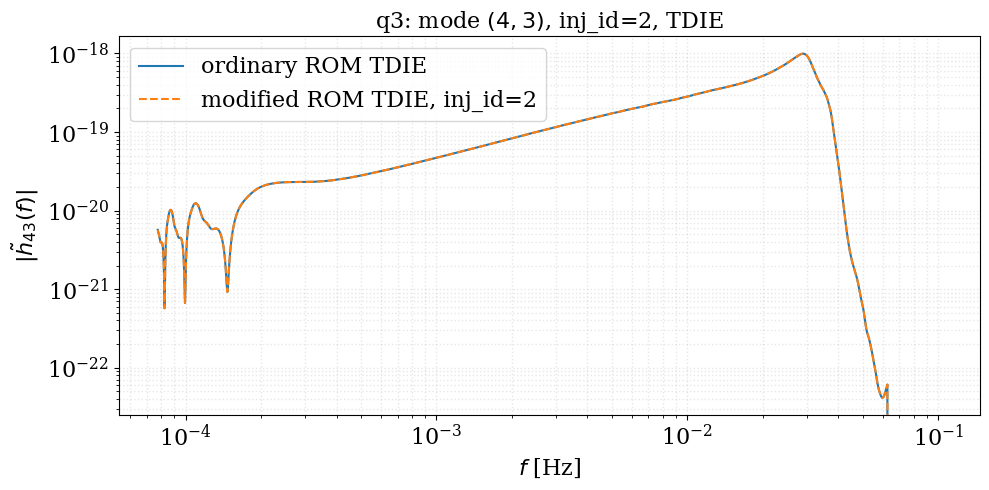

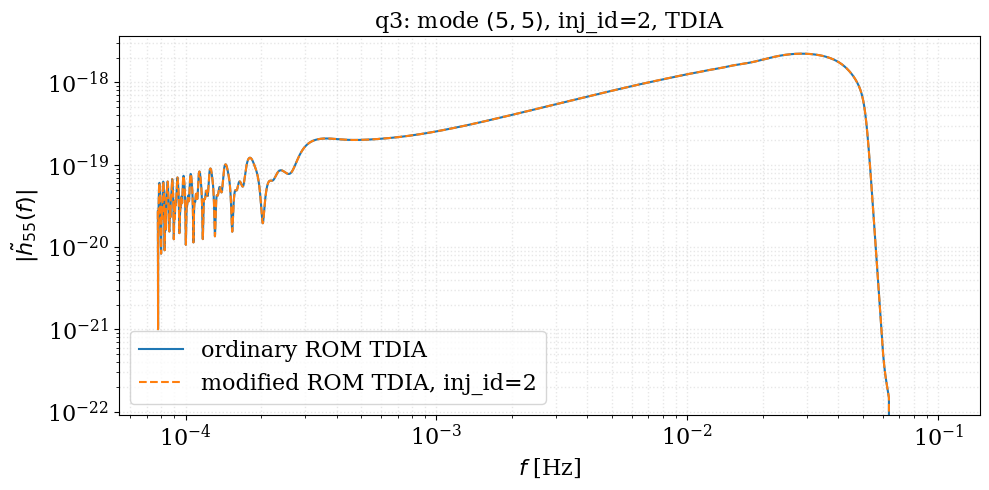

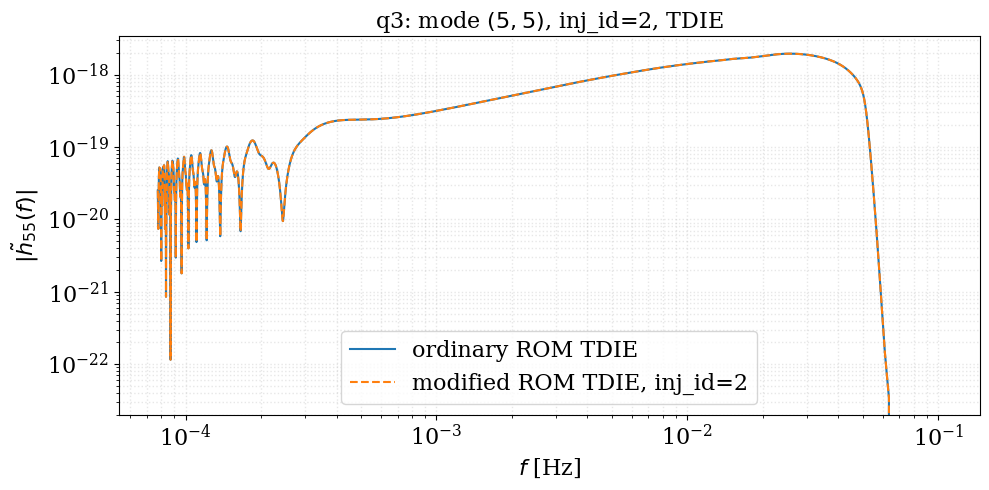

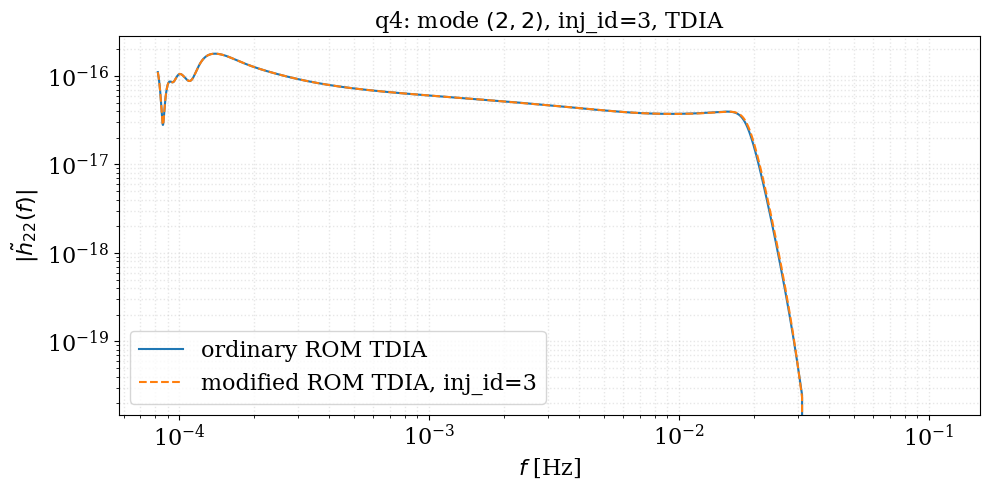

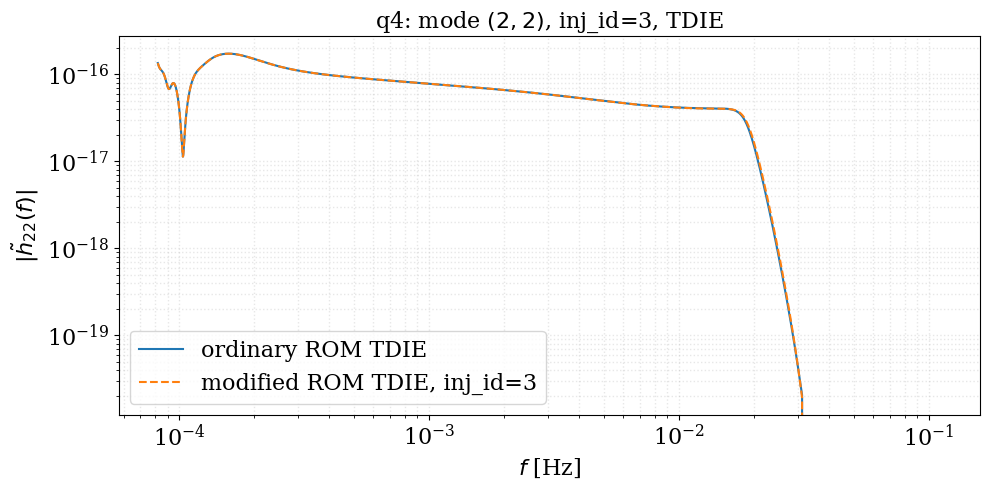

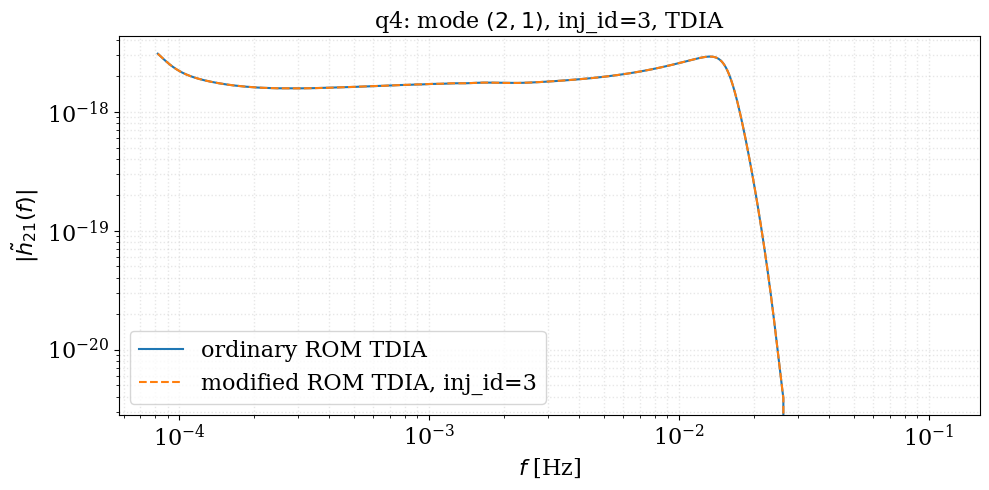

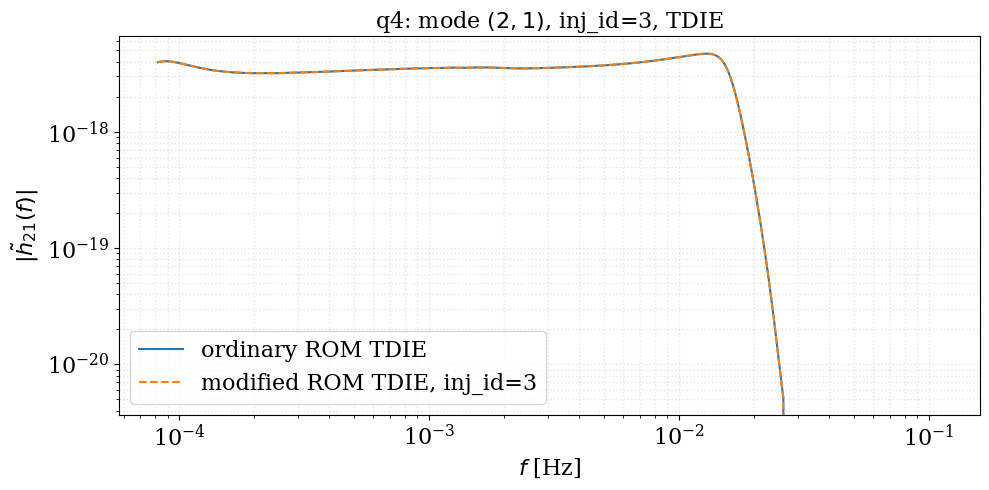

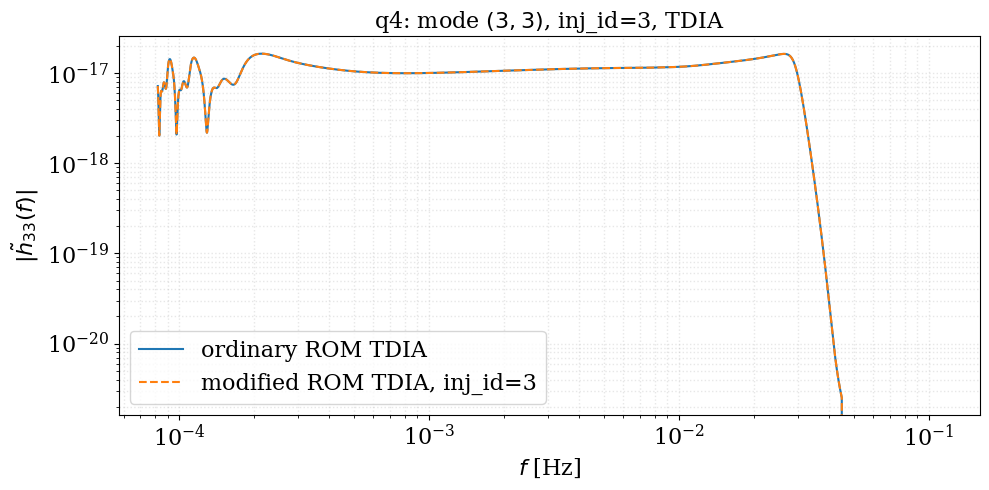

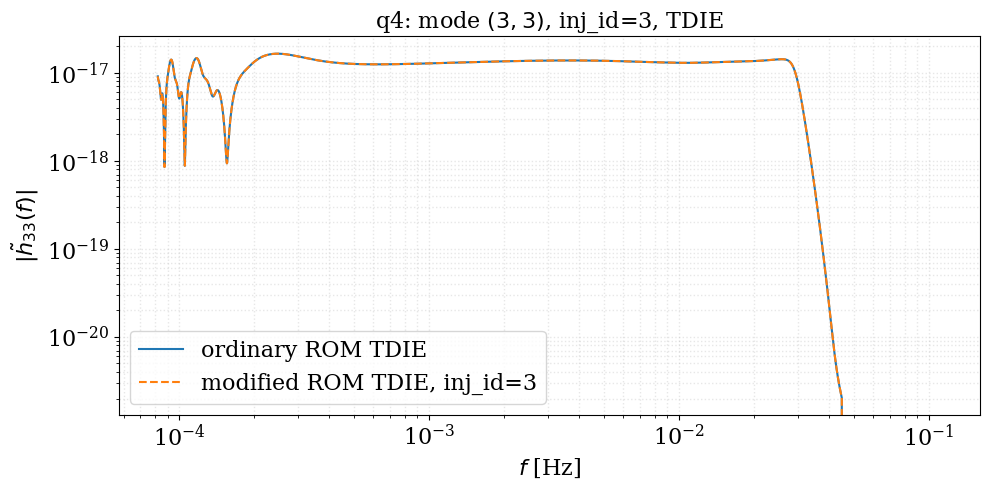

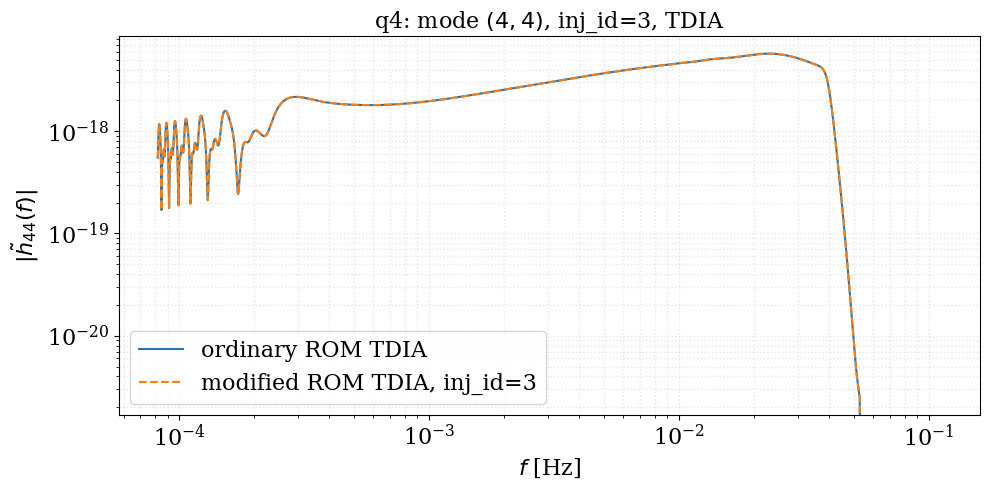

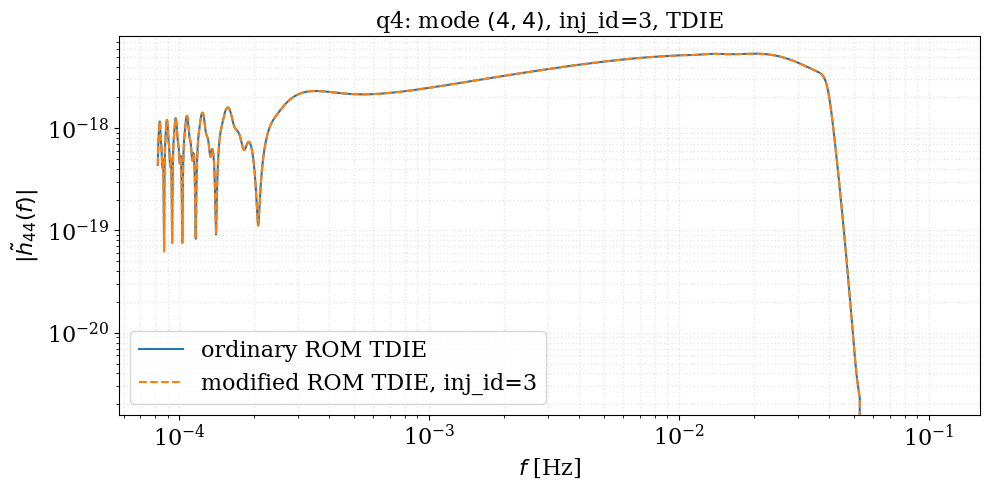

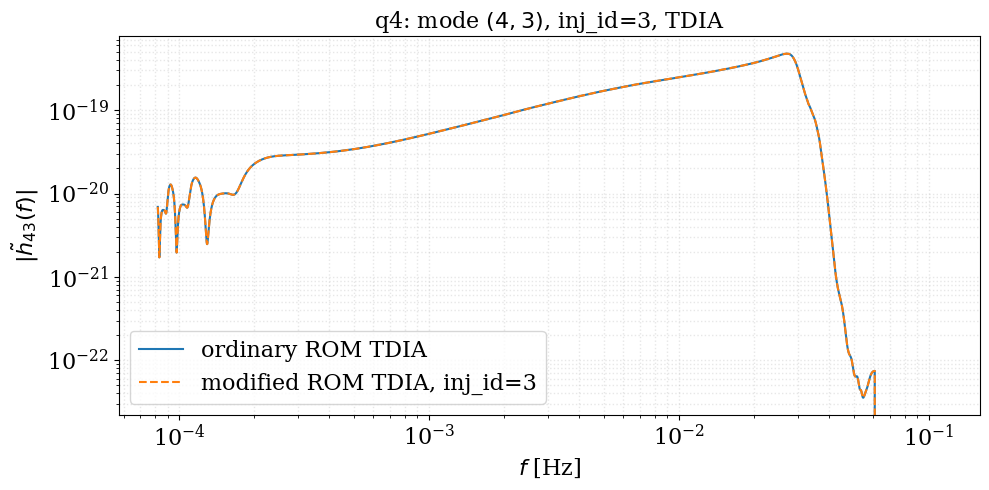

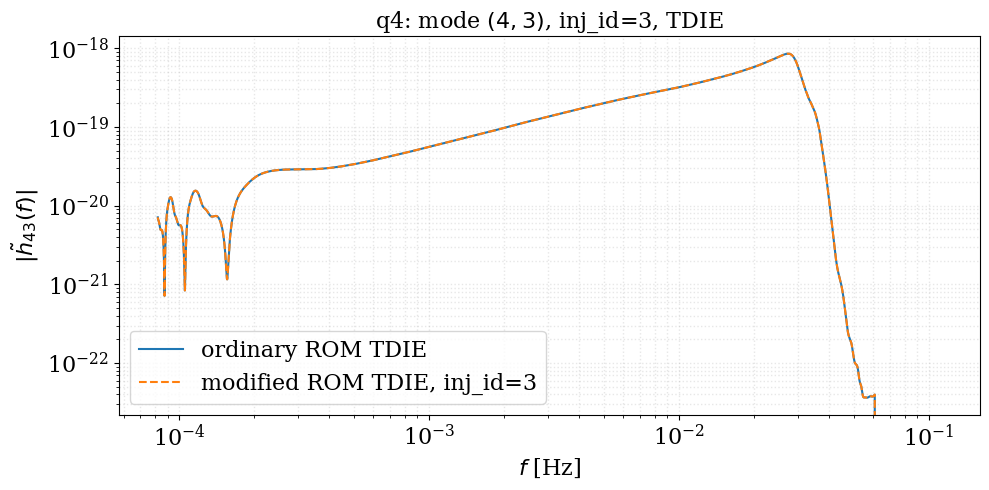

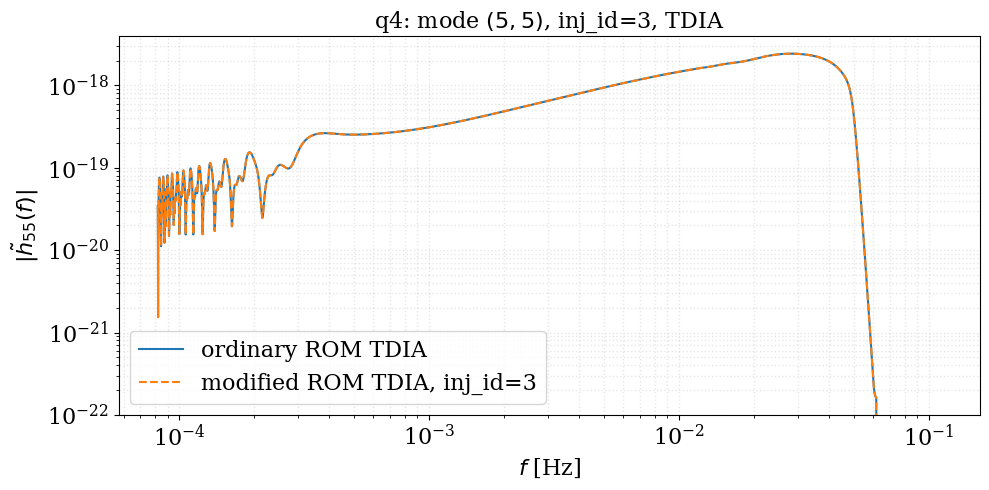

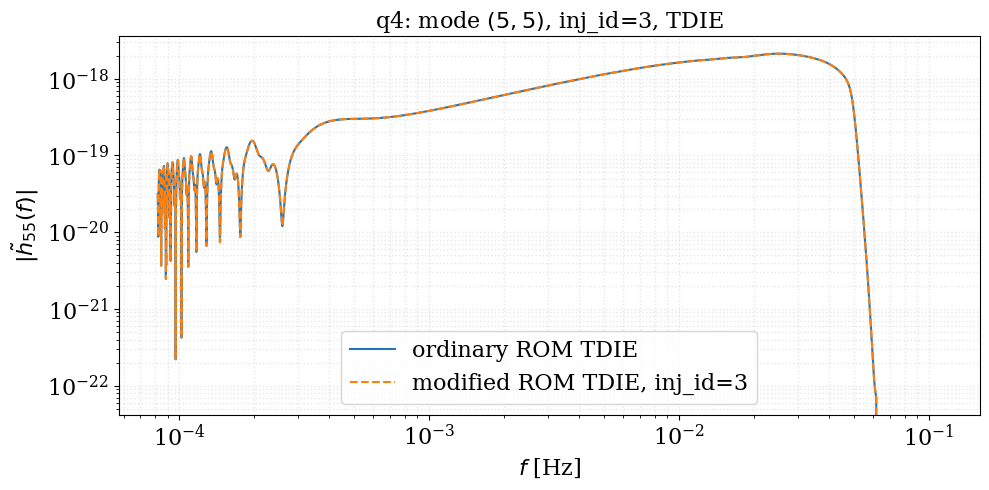

In [20]:
for q_label, case in consistency_cases.items():
    for lm in common_modes:
        if lm not in case["rom_modes"] or lm not in case["modified_modes"]:
            continue

        for channel in ("TDIA", "TDIE"):
            plt.figure(figsize=(10, 5))
            plt.loglog(
                case["rom_modes"][lm]["freq"],
                np.abs(case["rom_modes"][lm][channel]),
                label=f"ordinary ROM {channel}",
            )
            plt.loglog(
                case["modified_modes"][lm]["freq"],
                np.abs(case["modified_modes"][lm][channel]),
                "--",
                label=f"modified ROM {channel}, inj_id={case['case_id']}",
            )
            plt.xlabel(r"$f$ [Hz]")
            plt.ylabel(rf"$|\tilde{{h}}_{{{lm[0]}{lm[1]}}}(f)|$")
            plt.title(
                rf"{q_label}: mode $({lm[0]},{lm[1]})$, "
                rf"inj_id={case['case_id']}, {channel}"
            )
            plt.legend()
            plt.grid(True, which="both", alpha=0.3)
            plt.tight_layout()
            plt.show()


In [21]:
multiplier_rows = []

for q_label, case in consistency_cases.items():
    params_check = case["params"]

    with h5py.File(case["multiplier_file"], "r") as hf:
        multiplier_domega = float(
            hf.attrs.get("d_omega", params_check["d_omega"])
        )
        multiplier_dtau = float(
            hf.attrs.get("d_tau", params_check["d_tau"])
        )

        if not np.isclose(multiplier_domega, params_check["d_omega"]):
            raise ValueError(
                f"Multiplier d_omega mismatch for {q_label}, "
                f"inj_id={case['case_id']}"
            )
        if not np.isclose(multiplier_dtau, params_check["d_tau"]):
            raise ValueError(
                f"Multiplier d_tau mismatch for {q_label}, "
                f"inj_id={case['case_id']}"
            )

        for group in hf.keys():
            freq = hf[group]["freq"][:]
            amp_ratio = hf[group]["amp_ratio"][:]
            dphase = hf[group]["dphase"][:]

            good = (
                np.isfinite(freq)
                & np.isfinite(amp_ratio)
                & np.isfinite(dphase)
                & (freq > 0)
            )
            if not np.any(good):
                continue

            freq = freq[good]
            amp_ratio = amp_ratio[good]
            dphase = dphase[good]
            multiplier = amp_ratio * np.exp(1j * dphase)

            multiplier_rows.append({
                "mass_label": MASS_LABEL,
                "q_label": q_label,
                "q": case["q_value"],
                "M": case["mass_value"],
                "mode": group,
                "N": len(freq),
                "f_min": np.min(freq),
                "f_max": np.max(freq),
                "max_abs_amp_ratio_minus_1": np.max(
                    np.abs(amp_ratio - 1.0)
                ),
                "rms_amp_ratio_minus_1": np.sqrt(
                    np.mean(np.abs(amp_ratio - 1.0) ** 2)
                ),
                "max_abs_dphase": np.max(np.abs(dphase)),
                "rms_dphase": np.sqrt(np.mean(dphase ** 2)),
                "max_abs_multiplier_minus_1": np.max(
                    np.abs(multiplier - 1.0)
                ),
                "rms_multiplier_minus_1": np.sqrt(
                    np.mean(np.abs(multiplier - 1.0) ** 2)
                ),
            })

df_multiplier_check = pd.DataFrame(multiplier_rows)
display(df_multiplier_check)


,mass_label,q_label,q,M,mode,N,f_min,f_max,max_abs_amp_ratio_minus_1,rms_amp_ratio_minus_1,max_abs_dphase,rms_dphase,max_abs_multiplier_minus_1,rms_multiplier_minus_1
0,M1e6,q1,1.0,1000000.0,h22,9439,0.00001,0.114741,5.877341e-01,5.090019e-02,0.696641,0.097639,0.658171,0.105349
1,M1e6,q1,1.0,1000000.0,h44,10000,0.00001,0.200000,3.568845e-06,1.497404e-07,0.007353,0.001653,0.007353,0.001653
2,M1e6,q2,2.0,1000000.0,h21,9793,0.00001,0.162926,3.494489e-09,6.475385e-11,0.121005,0.027485,0.120931,0.027477
3,M1e6,q2,2.0,1000000.0,h22,9400,0.00001,0.110393,3.355545e-01,4.418392e-02,0.435614,0.103672,0.429544,0.108782
4,M1e6,q2,2.0,1000000.0,h33,10000,0.00001,0.200000,4.479970e-09,9.271236e-11,0.148542,0.033390,0.148405,0.033374
5,M1e6,q2,2.0,1000000.0,h43,10000,0.00001,0.200000,3.059903e-10,2.993594e-11,0.148542,0.033390,0.148405,0.033374
6,M1e6,q2,2.0,1000000.0,h44,10000,0.00001,0.200000,2.410164e-10,5.641772e-12,0.148542,0.033390,0.148405,0.033374
7,M1e6,q2,2.0,1000000.0,h55,10000,0.00001,0.200000,4.131688e-09,4.258428e-10,0.148542,0.033390,0.148405,0.033374
8,M1e6,q3,3.0,1000000.0,h21,9645,0.00001,0.140711,3.532212e-08,7.535928e-09,0.186413,0.042666,0.186143,0.042635
9,M1e6,q3,3.0,1000000.0,h22,9325,0.00001,0.102490,2.404031e-01,3.231118e-02,0.384283,0.110121,0.374944,0.112370


In [22]:
mode_rows = []

for q_label, case in consistency_cases.items():
    for lm in common_modes:
        if lm not in case["rom_modes"] or lm not in case["modified_modes"]:
            continue

        group = f"h{lm[0]}{lm[1]}"

        for channel in ("TDIA", "TDIE"):
            rom_h = case["rom_modes"][lm][channel]
            modified_h = case["modified_modes"][lm][channel]

            if rom_h.shape != modified_h.shape:
                raise ValueError(
                    f"Shape mismatch for {q_label}, inj_id={case['case_id']}, "
                    f"mode={lm}, channel={channel}: "
                    f"{rom_h.shape} != {modified_h.shape}"
                )

            scale = np.max(np.abs(rom_h))
            abs_diff = np.abs(modified_h - rom_h)

            mode_rows.append({
                "mass_label": MASS_LABEL,
                "q_label": q_label,
                "q": case["q_value"],
                "M": case["mass_value"],
                "mode": group,
                "channel": channel,
                "max_abs_modified_minus_ROM": np.max(abs_diff),
                "relative_to_max_ROM": (
                    np.max(abs_diff) / scale if scale > 0 else np.nan
                ),
                "rms_relative_to_max_ROM": (
                    np.sqrt(np.mean(abs_diff ** 2)) / scale
                    if scale > 0 else np.nan
                ),
                "max_ROM_amp": scale,
                "max_modified_amp": np.max(np.abs(modified_h)),
            })

df_mode_check = pd.DataFrame(mode_rows)
display(df_mode_check)


,mass_label,q_label,q,M,mode,channel,max_abs_modified_minus_ROM,relative_to_max_ROM,rms_relative_to_max_ROM,max_ROM_amp,max_modified_amp
0,M1e6,q1,1.0,1000000.0,h22,TDIA,4.798979e-18,0.020829,0.003185,2.303981e-16,2.304048e-16
1,M1e6,q1,1.0,1000000.0,h22,TDIE,4.511384e-18,0.020206,0.003116,2.232680e-16,2.232695e-16
2,M1e6,q1,1.0,1000000.0,h21,TDIA,0.000000e+00,0.000000,0.000000,1.996960e-23,1.996960e-23
3,M1e6,q1,1.0,1000000.0,h21,TDIE,0.000000e+00,0.000000,0.000000,4.149000e-23,4.149000e-23
4,M1e6,q1,1.0,1000000.0,h33,TDIA,0.000000e+00,0.000000,0.000000,1.018154e-23,1.018154e-23
5,M1e6,q1,1.0,1000000.0,h33,TDIE,0.000000e+00,0.000000,0.000000,1.305547e-23,1.305547e-23
6,M1e6,q1,1.0,1000000.0,h44,TDIA,5.704724e-21,0.001143,0.000346,4.991508e-18,4.991508e-18
7,M1e6,q1,1.0,1000000.0,h44,TDIE,4.673254e-21,0.001054,0.000344,4.432778e-18,4.432778e-18
8,M1e6,q1,1.0,1000000.0,h43,TDIA,0.000000e+00,0.000000,0.000000,5.924271e-24,5.924271e-24
9,M1e6,q1,1.0,1000000.0,h43,TDIE,0.000000e+00,0.000000,0.000000,6.578694e-24,6.578694e-24


In [23]:
total_rows = []

for q_label, case in consistency_cases.items():
    for channel in ("TDIA", "TDIE"):
        rom_h = case["rom_tdi"][channel]
        modified_h = case["modified_tdi"][channel]

        if rom_h.shape != modified_h.shape:
            raise ValueError(
                f"Total shape mismatch for {q_label}, "
                f"inj_id={case['case_id']}, channel={channel}: "
                f"{rom_h.shape} != {modified_h.shape}"
            )

        scale = np.max(np.abs(rom_h))
        abs_diff = np.abs(modified_h - rom_h)

        total_rows.append({
            "mass_label": MASS_LABEL,
                "q_label": q_label,
                "q": case["q_value"],
            "M": case["mass_value"],
            "channel": channel,
            "max_abs_saved_modified_minus_ROM": np.max(abs_diff),
            "relative_to_max_ROM": (
                np.max(abs_diff) / scale if scale > 0 else np.nan
            ),
            "rms_relative_to_max_ROM": (
                np.sqrt(np.mean(abs_diff ** 2)) / scale
                if scale > 0 else np.nan
            ),
            "max_ROM_amp": scale,
            "max_saved_modified_amp": np.max(np.abs(modified_h)),
        })

df_total_check = pd.DataFrame(total_rows)
display(df_total_check)


,mass_label,q_label,q,M,channel,max_abs_saved_modified_minus_ROM,relative_to_max_ROM,rms_relative_to_max_ROM,max_ROM_amp,max_saved_modified_amp
0,M1e6,q1,1.0,1000000.0,TDIA,4.799359e-18,0.020791,0.003180,2.308370e-16,2.308446e-16
1,M1e6,q1,1.0,1000000.0,TDIE,4.511551e-18,0.020132,0.003104,2.241023e-16,2.241023e-16
2,M1e6,q2,2.0,1000000.0,TDIA,4.676150e-18,0.021129,0.003423,2.213135e-16,2.213063e-16
3,M1e6,q2,2.0,1000000.0,TDIE,4.456346e-18,0.020908,0.003469,2.131408e-16,2.131404e-16
4,M1e6,q3,3.0,1000000.0,TDIA,3.745989e-18,0.018443,0.003491,2.031168e-16,2.031196e-16
5,M1e6,q3,3.0,1000000.0,TDIE,3.626634e-18,0.018493,0.003600,1.961077e-16,1.961066e-16
6,M1e6,q4,4.0,1000000.0,TDIA,3.041230e-18,0.016402,0.003402,1.854195e-16,1.854154e-16
7,M1e6,q4,4.0,1000000.0,TDIE,3.002602e-18,0.016623,0.003466,1.806241e-16,1.806243e-16


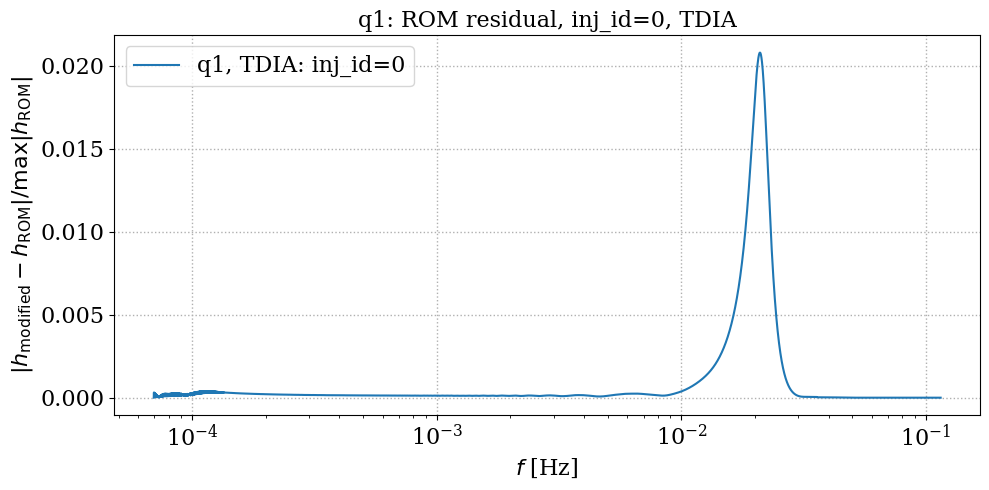

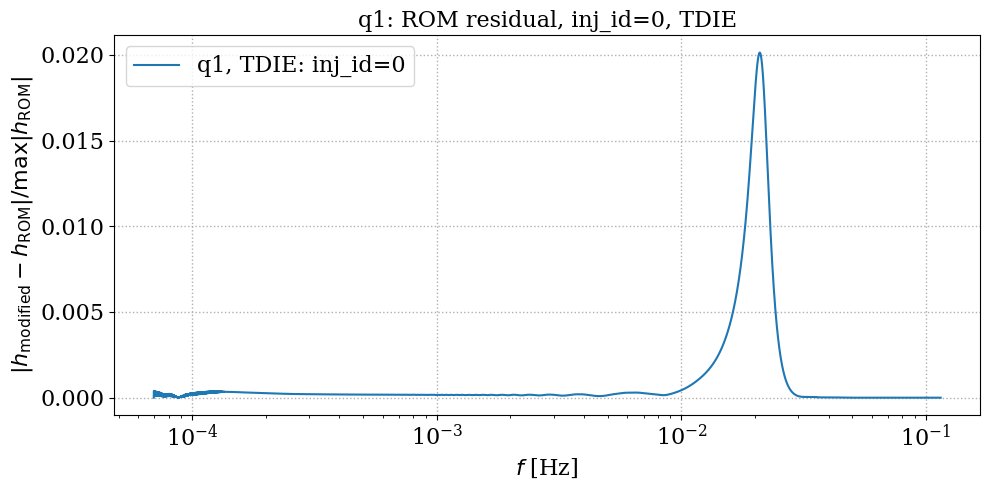

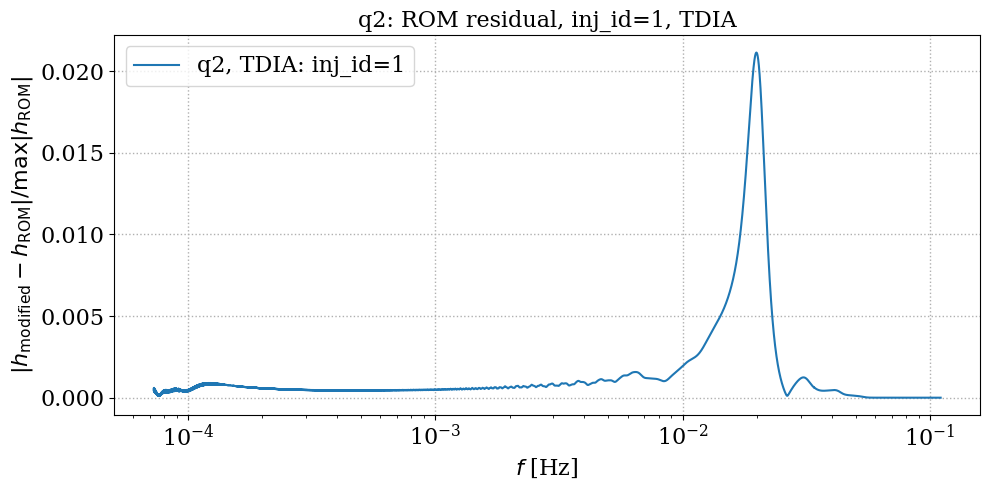

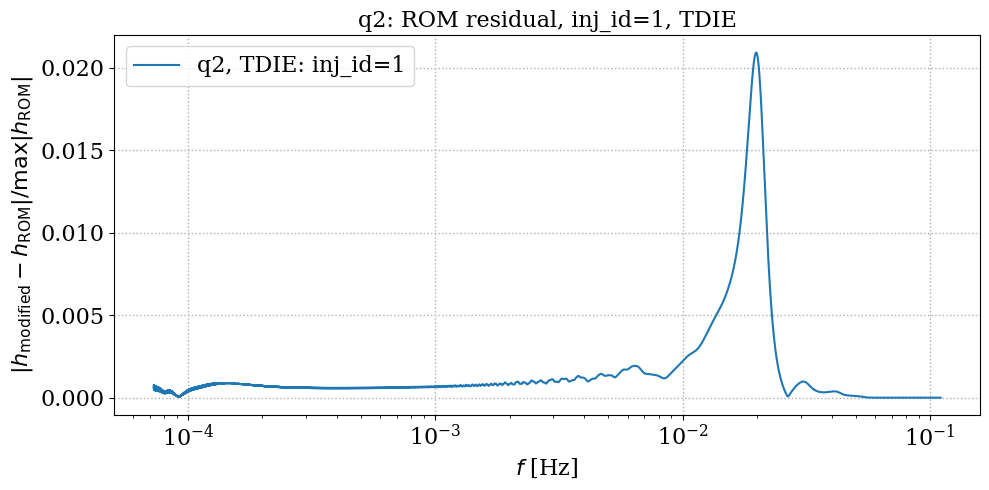

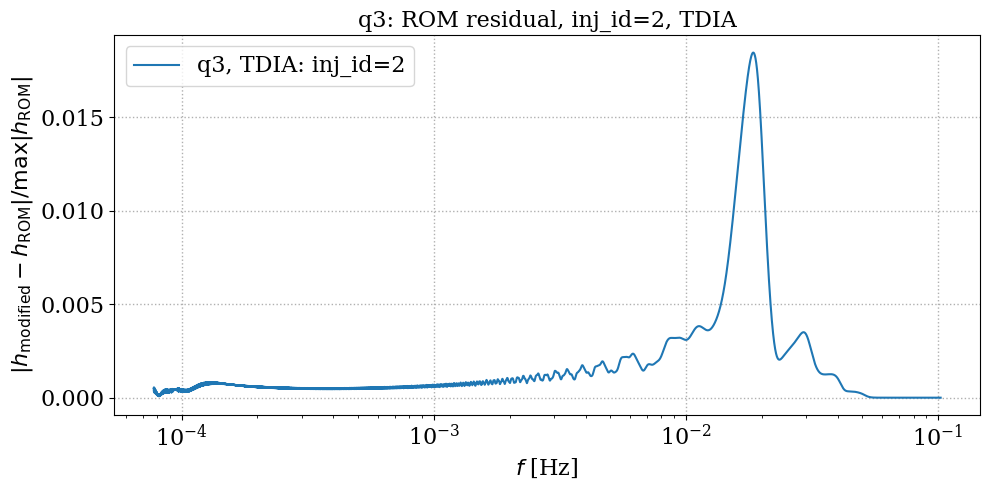

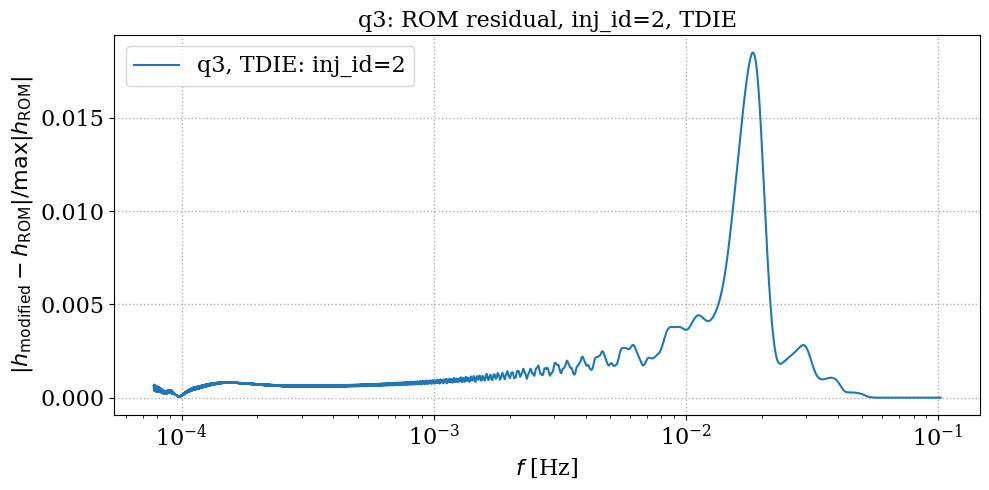

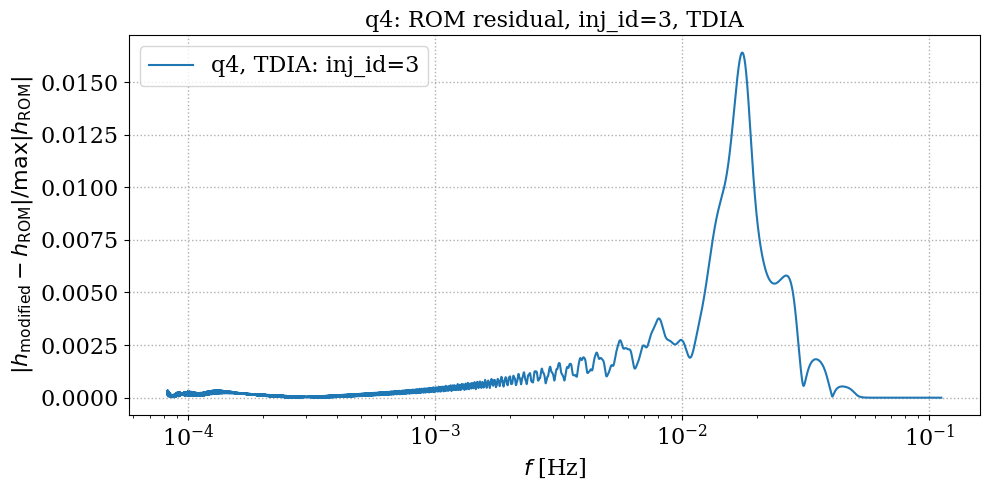

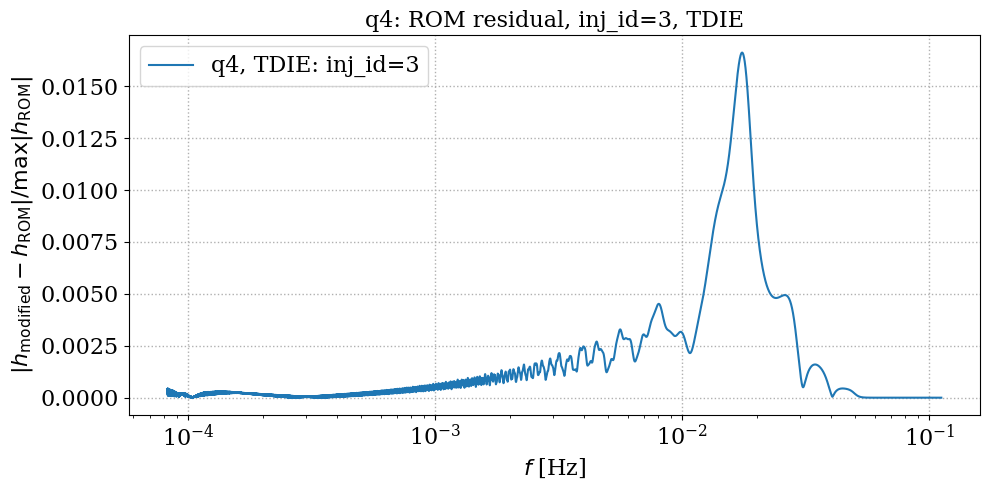

In [24]:
for q_label, case in consistency_cases.items():
    for channel in ("TDIA", "TDIE"):
        scale = np.max(np.abs(case["rom_tdi"][channel]))

        plt.figure(figsize=(10, 5))
        plt.semilogx(
            case["rom_tdi"]["freq"],
            np.abs(
                case["modified_tdi"][channel]
                - case["rom_tdi"][channel]
            ) / scale,
            label=f"{q_label}, {channel}: inj_id={case['case_id']}",
        )
        plt.xlabel(r"$f$ [Hz]")
        plt.ylabel(
            r"$|h_{\rm modified}-h_{\rm ROM}|/"
            r"\max|h_{\rm ROM}|$"
        )
        plt.title(
            f"{q_label}: ROM residual, "
            f"inj_id={case['case_id']}, {channel}"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()


In [25]:
tol = 1e-10
consistency_rows = []

for q_label, case in consistency_cases.items():
    summed_modes = {
        channel: np.zeros_like(case["modified_tdi"][channel])
        for channel in ("TDIA", "TDIE")
    }
    for mode_data in case["modified_modes"].values():
        for channel in ("TDIA", "TDIE"):
            summed_modes[channel] += mode_data[channel]

    reconstruction_errors = {}
    for channel in ("TDIA", "TDIE"):
        scale = np.max(np.abs(case["modified_tdi"][channel]))
        error = np.max(np.abs(summed_modes[channel] - case["modified_tdi"][channel]))
        reconstruction_errors[channel] = error / scale if scale > 0 else error

    params_check = case["params"]
    labels_match = (
        np.isclose(params_check["M"], MASS_VALUE)
        and np.isclose(params_check["q"], case["q_value"])
        and np.isclose(params_check["d_omega"], DEVIATION_VALUE)
        and np.isclose(params_check["d_tau"], DEVIATION_VALUE)
    )
    finite_data = all(
        np.all(np.isfinite(case["modified_tdi"][channel]))
        for channel in ("TDIA", "TDIE")
    )
    passed = (
        labels_match
        and finite_data
        and max(reconstruction_errors.values()) < tol
    )

    consistency_rows.append({
        "mass_label": MASS_LABEL,
        "M": MASS_VALUE,
        "q_label": q_label,
        "q": case["q_value"],
        "case_id": case["case_id"],
        "d_omega": params_check["d_omega"],
        "d_tau": params_check["d_tau"],
        "TDIA_mode_sum_relative_error": reconstruction_errors["TDIA"],
        "TDIE_mode_sum_relative_error": reconstruction_errors["TDIE"],
        "status": "PASS" if passed else "FAIL",
    })

df_consistency_check = pd.DataFrame(consistency_rows)
display(df_consistency_check)

if not np.all(df_consistency_check["status"] == "PASS"):
    raise RuntimeError("At least one saved q-scan injection failed consistency checks.")


,mass_label,M,q_label,q,case_id,d_omega,d_tau,TDIA_mode_sum_relative_error,TDIE_mode_sum_relative_error,status
0,M1e6,1000000.0,q1,1.0,0,0.01,0.01,0.0,0.0,PASS
1,M1e6,1000000.0,q2,2.0,1,0.01,0.01,0.0,0.0,PASS
2,M1e6,1000000.0,q3,3.0,2,0.01,0.01,0.0,0.0,PASS
3,M1e6,1000000.0,q4,4.0,3,0.01,0.01,0.0,0.0,PASS
